Air pollution Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
#Before Running the code you have to load 65 csv files on colab and MODIS and LANDSAT 5 years data

In [2]:


# ============================================================
# ALIPUR CPCB MISSINGNESS TEST: 5 YEARLY TABLES, 6 POLLUTANTS
# ============================================================

base_path = Path("/content")

pollutants = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)"
]

all_csvs = list(base_path.glob("*.csv"))
alipur_files_found = [
    f for f in all_csvs
    if "alipur" in f.name.lower() and "1h" in f.name.lower()
]

print("Alipur files found:")
for f in alipur_files_found:
    print(" -", f.name)

# Year mapping based on your confirmed CPCB filename convention:
# normal = 2024, (1) = 2023, (2) = 2022, (3) = 2021, (4) = 2020
def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

alipur_files = {
    detect_year_from_filename(f.name): f
    for f in alipur_files_found
}

print("\nYear-file mapping:")
for year in sorted(alipur_files):
    print(year, "->", alipur_files[year].name)

def missingness_for_one_year(file_path, year):
    df = pd.read_csv(file_path)


    df.columns = df.columns.str.strip()


    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")


    df = df.dropna(subset=["Timestamp"]).copy()

    df = df[df["Timestamp"].dt.year == year].copy()

    for col in pollutants:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            print(f"WARNING: {col} not found in {file_path.name}")

    full_hours = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        end=f"{year}-12-31 23:00:00",
        freq="h"
    )


    df = df.drop_duplicates(subset="Timestamp", keep="first")

    df_full = df.set_index("Timestamp").reindex(full_hours)
    df_full.index.name = "Timestamp"

    rows = []

    # Monthly missingness
    for month in range(1, 13):
        month_df = df_full[df_full.index.month == month]

        row = {"Month": month}

        for col in pollutants:
            if col in df_full.columns:
                row[col] = round(month_df[col].isna().mean() * 100, 2)
            else:
                row[col] = 100.00

        rows.append(row)

    # Annual missingness
    annual_row = {"Month": "Annual"}

    for col in pollutants:
        if col in df_full.columns:
            annual_row[col] = round(df_full[col].isna().mean() * 100, 2)
        else:
            annual_row[col] = 100.00

    rows.append(annual_row)

    return pd.DataFrame(rows)

alipur_missing_tables = {}

for year in [2020, 2021, 2022, 2023, 2024]:
    print("\n" + "=" * 90)
    print(f"ALIPUR MISSINGNESS TABLE: {year}")

    if year not in alipur_files:
        print(f"ERROR: Alipur file for {year} not found.")
        continue

    table = missingness_for_one_year(alipur_files[year], year)
    alipur_missing_tables[year] = table
    display(table)

output_file = base_path / "Alipur_Missingness_2020_2024.xlsx"

with pd.ExcelWriter(output_file) as writer:
    for year, table in alipur_missing_tables.items():
        table.to_excel(writer, sheet_name=str(year), index=False)

print("\nSaved Excel file:", output_file)

Alipur files found:
 - raw_data_hourly_alipur,_delhi_-_dpcc_1H (2).csv
 - raw_data_hourly_alipur,_delhi_-_dpcc_1H (1).csv
 - raw_data_hourly_alipur,_delhi_-_dpcc_1H.csv
 - raw_data_hourly_alipur,_delhi_-_dpcc_1H (4).csv
 - raw_data_hourly_alipur,_delhi_-_dpcc_1H (3).csv

Year-file mapping:
2020 -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (4).csv
2021 -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (3).csv
2022 -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (2).csv
2023 -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (1).csv
2024 -> raw_data_hourly_alipur,_delhi_-_dpcc_1H.csv

ALIPUR MISSINGNESS TABLE: 2020


,Month,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,1,1.88,2.02,1.08,10.48,1.75,2.02
1,2,8.62,3.02,2.73,14.08,2.59,3.59
2,3,5.24,5.24,4.17,2.82,5.11,13.44
3,4,0.42,1.25,0.42,0.14,0.42,0.42
4,5,2.55,2.55,2.42,2.15,2.42,2.42
5,6,8.89,8.89,13.47,8.61,10.83,11.11
6,7,10.08,10.08,14.92,7.26,7.80,21.10
7,8,8.87,7.66,12.90,47.31,5.65,27.55
8,9,3.89,5.97,4.17,30.14,3.89,8.47
9,10,2.02,1.21,2.28,0.94,3.76,2.96



ALIPUR MISSINGNESS TABLE: 2021


,Month,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,1,0.81,0.81,0.81,0.94,7.53,1.75
1,2,4.32,6.10,8.18,11.16,8.33,20.83
2,3,11.29,11.29,16.80,20.16,14.52,20.56
3,4,2.64,2.50,2.08,33.47,2.22,11.81
4,5,1.21,2.28,2.96,7.66,4.17,5.24
5,6,1.67,2.50,1.25,12.92,1.25,12.50
6,7,7.53,8.06,4.17,10.62,5.38,4.30
7,8,4.97,4.57,1.08,9.41,1.34,2.28
8,9,9.31,9.58,2.50,3.75,2.64,3.06
9,10,1.88,2.42,0.13,2.15,0.13,0.13



ALIPUR MISSINGNESS TABLE: 2022


...


ALIPUR MISSINGNESS TABLE: 2023


,Month,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,1,4.97,4.97,3.49,8.47,3.63,3.76
1,2,1.19,0.89,0.00,0.00,0.00,0.60
2,3,6.59,5.78,4.70,11.02,4.70,5.78
3,4,0.00,0.42,0.42,4.44,0.00,1.53
4,5,1.21,4.03,1.34,6.72,1.34,6.59
5,6,5.56,5.97,5.14,8.47,5.42,11.11
6,7,28.49,34.41,24.06,27.55,23.52,23.39
7,8,5.11,4.97,10.08,8.60,6.18,6.05
8,9,1.67,1.25,0.97,6.39,0.97,1.67
9,10,0.54,2.15,3.36,5.51,3.23,6.32



ALIPUR MISSINGNESS TABLE: 2024


,Month,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,1,0.54,0.13,8.60,0.00,0.00,0.00
1,2,0.29,2.59,0.86,0.00,0.86,0.00
2,3,4.44,4.03,0.81,1.34,0.81,2.69
3,4,0.83,0.83,1.11,1.81,1.11,1.11
4,5,0.94,1.21,1.88,9.95,1.88,4.03
5,6,2.22,2.22,0.97,3.75,1.11,5.28
6,7,1.88,1.88,1.48,4.17,1.61,5.78
7,8,1.75,1.61,0.54,2.96,1.08,5.24
8,9,7.22,6.25,4.44,8.06,6.25,8.19
9,10,4.70,4.57,3.36,4.30,4.30,7.26



Saved Excel file: /content/Alipur_Missingness_2020_2024.xlsx


In [3]:

# ============================================================
# STATIONWISE POLLUTANT MISSINGNESS: 13 STATIONS x 6 POLLUTANTS
# Average missingness over 2020-2024
# ============================================================

base_path = Path("/content")

pollutants = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)"
]

stations = {
    "TERI Gram, Gurugram": ["teri", "gram"],
    "Dr Karni Singh Shooting Range, Delhi": ["karni", "shooting"],
    "Sri Aurobindo Marg": ["aurobindo"],
    "Narela": ["narela"],
    "Najafgarh": ["najafgarh"],
    "Alipur": ["alipur"],
    "Bawana": ["bawana"],
    "Vivek Vihar, Delhi": ["vivek", "vihar"],
    "Punjabi Bagh, Delhi": ["punjabi", "bagh"],
    "Rohini, Delhi": ["rohini"],
    "Wazirpur, Delhi": ["wazirpur"],
    "ITO, New Delhi": ["ito"],
    "Mandir Marg, New Delhi": ["mandir", "marg"]
}

def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

def find_station_files(station_name, search_terms):
    all_csvs = list(base_path.glob("*.csv"))


    all_csvs = [
        f for f in all_csvs
        if "missingness" not in f.name.lower()
        and "average" not in f.name.lower()
    ]

    matched_files = []

    for f in all_csvs:
        fname = f.name.lower()

        if all(term.lower() in fname for term in search_terms) and "1h" in fname:
            matched_files.append(f)

    year_file_map = {}

    for f in matched_files:
        year = detect_year_from_filename(f.name)
        year_file_map[year] = f

    return year_file_map

def missingness_one_file(file_path, year):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Timestamp" not in df.columns:
        raise ValueError(f"Timestamp column not found in {file_path.name}")

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).copy()


    df = df[df["Timestamp"].dt.year == year].copy()


    for col in pollutants:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    full_hours = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        end=f"{year}-12-31 23:00:00",
        freq="h"
    )

    df = df.drop_duplicates(subset="Timestamp", keep="first")

    df_full = df.set_index("Timestamp").reindex(full_hours)
    df_full.index.name = "Timestamp"

    missing_percent = {}

    for col in pollutants:
        if col in df_full.columns:
            missing_percent[col] = round(df_full[col].isna().mean() * 100, 2)
        else:
            missing_percent[col] = 100.00

    return missing_percent

# ============================================================
# RUN FOR ALL 13 STATIONS
# ============================================================

stationwise_rows = []
yearwise_detail_rows = []

for station_name, search_terms in stations.items():

    print("\n" + "=" * 100)
    print("Station:", station_name)

    station_files = find_station_files(station_name, search_terms)

    print("Files detected:")
    for year in sorted(station_files):
        print(year, "->", station_files[year].name)

    yearly_missing_list = []

    for year in [2020, 2021, 2022, 2023, 2024]:

        if year not in station_files:
            print(f"WARNING: File missing for {station_name}, year {year}")

            missing_percent = {col: 100.00 for col in pollutants}

        else:
            missing_percent = missingness_one_file(station_files[year], year)

        yearly_missing_list.append(missing_percent)

        detail_row = {
            "Station": station_name,
            "Year": year
        }
        detail_row.update(missing_percent)
        yearwise_detail_rows.append(detail_row)


    station_row = {"Station": station_name}

    for col in pollutants:
        values = [year_data[col] for year_data in yearly_missing_list]
        station_row[col] = round(sum(values) / len(values), 2)

    stationwise_rows.append(station_row)

stationwise_missingness = pd.DataFrame(stationwise_rows)


stationwise_yearly_missingness = pd.DataFrame(yearwise_detail_rows)

print("\n" + "=" * 100)
print("FINAL TABLE: Average Missingness over 2020-2024")
display(stationwise_missingness)

print("\n" + "=" * 100)
print("CHECK TABLE: Year-wise Missingness")
display(stationwise_yearly_missingness)


output_avg = base_path / "Stationwise_Pollutant_Missingness_2020_2024.csv"
output_yearly = base_path / "Stationwise_Yearly_Average_Missingness_2020_2024.csv"

stationwise_missingness.to_csv(output_avg, index=False)
stationwise_yearly_missingness.to_csv(output_yearly, index=False)

print("\nSaved files:")
print(output_avg)
print(output_yearly)


Station: TERI Gram, Gurugram
Files detected:
2020 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (4).csv
2021 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (3).csv
2022 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (2).csv
2023 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (1).csv
2024 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H.csv

Station: Dr Karni Singh Shooting Range, Delhi
Files detected:
2020 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (4).csv
2021 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (3).csv
2022 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (2).csv
2023 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (1).csv
2024 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H.csv

Station: Sri Aurobindo Marg
Files detected:
2020 -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (4).csv
2021 -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (3).csv
202

,Station,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,"TERI Gram, Gurugram",9.88,9.34,9.39,7.07,11.74,5.52
1,"Dr Karni Singh Shooting Range, Delhi",4.62,1.99,4.78,4.57,4.88,5.28
2,Sri Aurobindo Marg,2.32,2.71,1.74,2.34,2.51,4.99
3,Narela,3.22,3.66,3.08,3.02,6.14,6.84
4,Najafgarh,6.91,6.70,6.42,6.63,7.81,6.20
5,Alipur,4.03,4.31,3.89,8.87,4.57,6.07
6,Bawana,3.44,2.93,3.45,3.19,5.54,5.46
7,"Vivek Vihar, Delhi",4.92,6.18,3.60,8.05,2.96,4.21
8,"Punjabi Bagh, Delhi",4.21,4.57,4.18,5.07,9.77,7.39
9,"Rohini, Delhi",2.35,1.82,2.22,4.63,3.63,3.70



CHECK TABLE: Year-wise Missingness


,Station,Year,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),Ozone (µg/m³),SO2 (µg/m³),CO (mg/m³)
0,"TERI Gram, Gurugram",2020,27.14,25.77,27.96,20.34,21.49,18.09
1,"TERI Gram, Gurugram",2021,4.13,4.11,0.82,0.49,1.53,0.17
2,"TERI Gram, Gurugram",2022,4.62,4.41,5.63,3.72,16.67,1.50
3,"TERI Gram, Gurugram",2023,3.24,2.85,2.11,1.58,9.46,1.05
4,"TERI Gram, Gurugram",2024,10.25,9.55,10.45,9.23,9.54,6.81
...,...,...,...,...,...,...,...,...
60,"Mandir Marg, New Delhi",2020,7.14,6.73,9.28,6.39,14.36,13.13
61,"Mandir Marg, New Delhi",2021,3.46,3.70,2.85,5.07,4.47,6.93
62,"Mandir Marg, New Delhi",2022,4.86,3.18,4.27,5.11,6.80,9.34
63,"Mandir Marg, New Delhi",2023,4.99,5.03,4.39,7.13,11.30,7.39



Saved files:
/content/Stationwise_Pollutant_Missingness_2020_2024.csv
/content/Stationwise_Yearly_Average_Missingness_2020_2024.csv


In [4]:


# ============================================================
# TEMPORAL POLLUTANT TABLE
# Yearly average concentrations of 6 air pollutants, 2020-2024
# Output style similar to YRD Table 4
# ============================================================

base_path = Path("/content")


pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]


stations = {
    "TERI Gram, Gurugram": ["teri", "gram"],
    "Dr Karni Singh Shooting Range, Delhi": ["karni", "shooting"],
    "Sri Aurobindo Marg": ["aurobindo"],
    "Narela": ["narela"],
    "Najafgarh": ["najafgarh"],
    "Alipur": ["alipur"],
    "Bawana": ["bawana"],
    "Vivek Vihar, Delhi": ["vivek", "vihar"],
    "Punjabi Bagh, Delhi": ["punjabi", "bagh"],
    "Rohini, Delhi": ["rohini"],
    "Wazirpur, Delhi": ["wazirpur"],
    "ITO, New Delhi": ["ito"],
    "Mandir Marg, New Delhi": ["mandir", "marg"]
}

# Filename suffix rule:
# normal = 2024, (1) = 2023, (2) = 2022, (3) = 2021, (4) = 2020
def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

def find_station_files(search_terms):
    all_csvs = list(base_path.glob("*.csv"))

    # Exclude already generated output tables
    all_csvs = [
        f for f in all_csvs
        if "missingness" not in f.name.lower()
        and "average" not in f.name.lower()
        and "yearly" not in f.name.lower()
        and "table" not in f.name.lower()
    ]

    matched_files = []

    for f in all_csvs:
        fname = f.name.lower()

        if all(term.lower() in fname for term in search_terms) and "1h" in fname:
            matched_files.append(f)

    year_file_map = {}

    for f in matched_files:
        year = detect_year_from_filename(f.name)
        year_file_map[year] = f

    return year_file_map

def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace("μ", "µ")
    name = name.replace("ug", "µg")
    name = name.replace("m3", "m³")
    name = name.replace(" ", "")
    return name

def get_column_map(df):
    normalized_columns = {normalize_name(col): col for col in df.columns}

    required_map = {
        "CO (mg/m³)": ["co(mg/m³)"],
        "NO2 (µg/m³)": ["no2(µg/m³)"],
        "Ozone (µg/m³)": ["ozone(µg/m³)", "o3(µg/m³)"],
        "PM2.5 (µg/m³)": ["pm2.5(µg/m³)", "pm25(µg/m³)"],
        "PM10 (µg/m³)": ["pm10(µg/m³)"],
        "SO2 (µg/m³)": ["so2(µg/m³)"]
    }

    column_map = {}

    for clean_name, possible_names in required_map.items():
        found_col = None

        for possible in possible_names:
            possible_norm = normalize_name(possible)

            if possible_norm in normalized_columns:
                found_col = normalized_columns[possible_norm]
                break

        column_map[clean_name] = found_col

    return column_map


yearly_data = {
    2020: [],
    2021: [],
    2022: [],
    2023: [],
    2024: []
}

file_check_rows = []

for station_name, search_terms in stations.items():

    station_files = find_station_files(search_terms)

    print("\n" + "=" * 100)
    print("Station:", station_name)

    for year in [2020, 2021, 2022, 2023, 2024]:

        if year not in station_files:
            print(f"WARNING: File missing for {station_name}, {year}")
            file_check_rows.append({
                "Station": station_name,
                "Year": year,
                "File": "MISSING",
                "Rows used": 0
            })
            continue

        file_path = station_files[year]
        print(year, "->", file_path.name)

        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()

        if "Timestamp" not in df.columns:
            print(f"WARNING: Timestamp column missing in {file_path.name}")
            file_check_rows.append({
                "Station": station_name,
                "Year": year,
                "File": file_path.name,
                "Rows used": 0
            })
            continue

        df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
        df = df.dropna(subset=["Timestamp"]).copy()
        df = df[df["Timestamp"].dt.year == year].copy()

        column_map = get_column_map(df)

        df_use = pd.DataFrame()
        df_use["Timestamp"] = df["Timestamp"]

        for clean_col in pollutants:
            original_col = column_map[clean_col]

            if original_col is None:
                print(f"WARNING: {clean_col} not found in {file_path.name}")
                df_use[clean_col] = pd.NA
            else:
                df_use[clean_col] = pd.to_numeric(df[original_col], errors="coerce")

        yearly_data[year].append(df_use)

        file_check_rows.append({
            "Station": station_name,
            "Year": year,
            "File": file_path.name,
            "Rows used": len(df_use)
        })


table_rows = []

for pollutant in pollutants:

    row = {"Air pollutants": pollutant}

    yearly_values = []

    for year in [2020, 2021, 2022, 2023, 2024]:

        if len(yearly_data[year]) == 0:
            yearly_mean = pd.NA
        else:
            year_df = pd.concat(yearly_data[year], ignore_index=True)
            yearly_mean = round(year_df[pollutant].mean(skipna=True), 2)

        row[year] = yearly_mean
        yearly_values.append(yearly_mean)

    numeric_values = [v for v in yearly_values if pd.notna(v)]
    row["Average"] = round(sum(numeric_values) / len(numeric_values), 2) if len(numeric_values) > 0 else pd.NA

    table_rows.append(row)

temporal_pollutant_table = pd.DataFrame(table_rows)

print("\n" + "=" * 100)
print("TABLE: Yearly average concentrations of air pollutants in Delhi-NCR during 2020-2024")
display(temporal_pollutant_table)

file_check_table = pd.DataFrame(file_check_rows)

print("\n" + "=" * 100)
print("FILE CHECK TABLE")
display(file_check_table)


output_table = base_path / "Table_Yearly_Average_Air_Pollutants_2020_2024.csv"
output_check = base_path / "File_Check_Air_Pollutants_2020_2024.csv"

temporal_pollutant_table.to_csv(output_table, index=False)
file_check_table.to_csv(output_check, index=False)

print("\nSaved files:")
print(output_table)
print(output_check)


Station: TERI Gram, Gurugram
2020 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (4).csv
2021 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (3).csv
2022 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (2).csv
2023 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (1).csv
2024 -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H.csv

Station: Dr Karni Singh Shooting Range, Delhi
2020 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (4).csv
2021 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (3).csv
2022 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (2).csv
2023 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (1).csv
2024 -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H.csv

Station: Sri Aurobindo Marg
2020 -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (4).csv
2021 -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (3).csv
2022 -> raw_data_hourly_sri_aurobindo_marg,_delhi_-

,Air pollutants,2020,2021,2022,2023,2024,Average
0,CO (mg/m³),1.30,1.24,1.13,1.14,1.21,1.20
1,NO2 (µg/m³),33.81,32.86,32.96,32.86,42.69,35.04
2,Ozone (µg/m³),31.45,29.41,28.18,26.54,36.82,30.48
3,PM2.5 (µg/m³),98.39,108.60,100.17,104.02,106.72,103.58
4,PM10 (µg/m³),178.44,203.84,208.00,204.83,204.33,199.89
5,SO2 (µg/m³),13.27,10.74,9.02,7.15,12.77,10.59



FILE CHECK TABLE


,Station,Year,File,Rows used
0,"TERI Gram, Gurugram",2020,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8784
1,"TERI Gram, Gurugram",2021,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8760
2,"TERI Gram, Gurugram",2022,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8760
3,"TERI Gram, Gurugram",2023,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8760
4,"TERI Gram, Gurugram",2024,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8784
...,...,...,...,...
60,"Mandir Marg, New Delhi",2020,"raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H (...",8784
61,"Mandir Marg, New Delhi",2021,"raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H (...",8760
62,"Mandir Marg, New Delhi",2022,"raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H (...",8760
63,"Mandir Marg, New Delhi",2023,"raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H (...",8760



Saved files:
/content/Table_Yearly_Average_Air_Pollutants_2020_2024.csv
/content/File_Check_Air_Pollutants_2020_2024.csv


SUHI + Pollutant Analysis


Pollutant deviation from 2020--2024 average:


,Air pollutants,2020,2021,2022,2023,2024
0,CO (mg/m³),0.10,0.04,-0.07,-0.06,0.01
1,NO2 (µg/m³),-1.23,-2.18,-2.08,-2.18,7.65
2,Ozone (µg/m³),0.97,-1.07,-2.30,-3.94,6.34
3,PM2.5 (µg/m³),-5.19,5.02,-3.41,0.44,3.14
4,PM10 (µg/m³),-21.45,3.95,8.11,4.94,4.44
5,SO2 (µg/m³),2.68,0.15,-1.57,-3.44,2.18


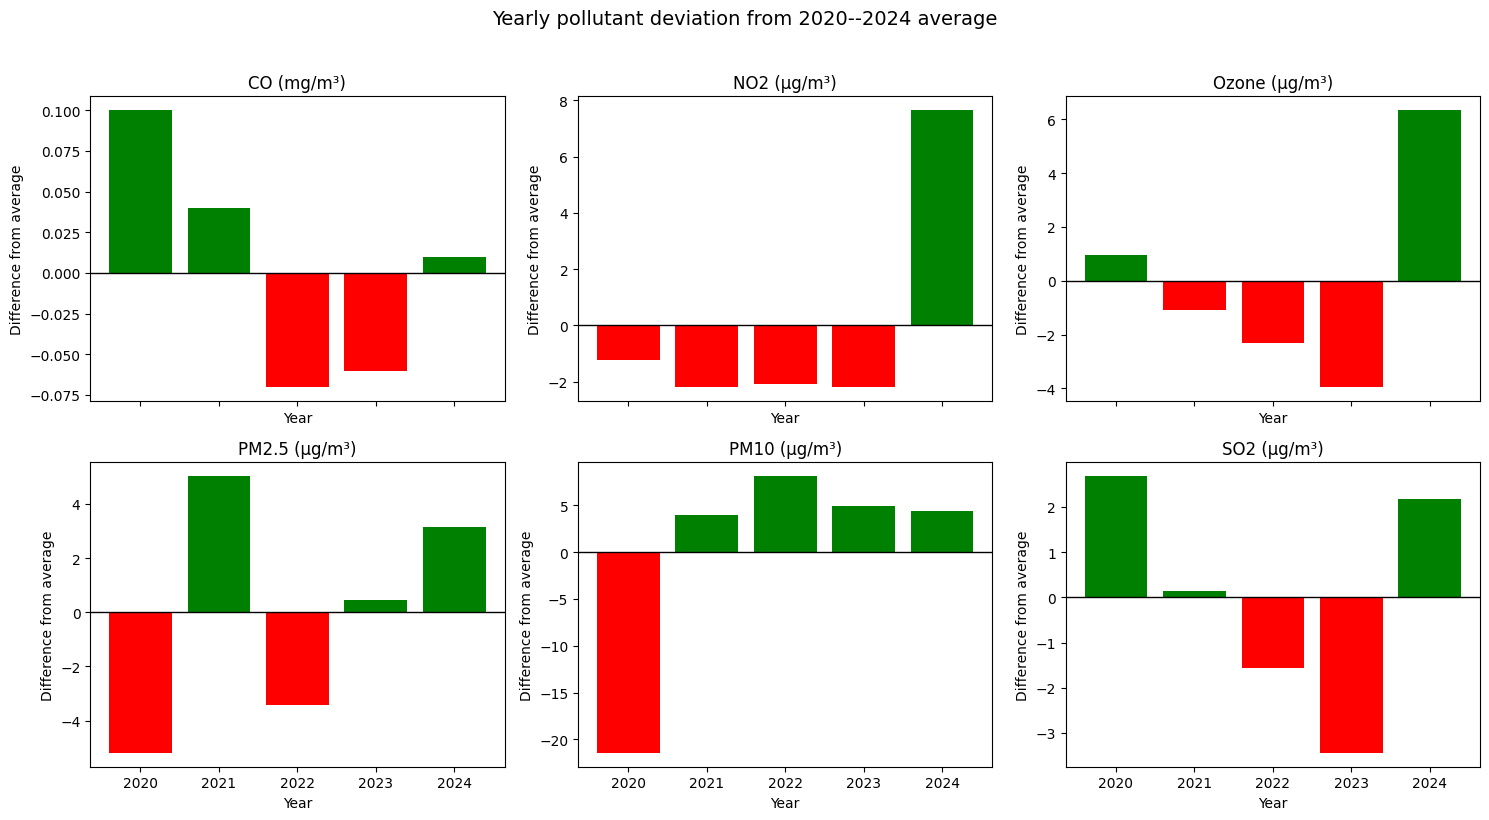

In [5]:
# ------------------------------------------------------------
# Block 3: One-image pollutant deviation plots
# Positive/negative comparison from 2020--2024 average
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

year_cols = [2020, 2021, 2022, 2023, 2024]

pollutant_deviation_table = temporal_pollutant_table.copy()

for year in year_cols:
    pollutant_deviation_table[year] = (
        pollutant_deviation_table[year] - pollutant_deviation_table["Average"]
    )

pollutant_deviation_table = pollutant_deviation_table[["Air pollutants"] + year_cols]

print("Pollutant deviation from 2020--2024 average:")
display(pollutant_deviation_table.round(2))

n_pollutants = len(pollutant_deviation_table)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True
)

axes = axes.flatten()

for i, (_, row) in enumerate(pollutant_deviation_table.iterrows()):
    pollutant = row["Air pollutants"]
    values = row[year_cols].astype(float).values

    colors = ["green" if v >= 0 else "red" for v in values]

    axes[i].bar([str(y) for y in year_cols], values, color=colors)
    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].set_title(pollutant)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Difference from average")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Yearly pollutant deviation from 2020--2024 average",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

Output path: /content/drive/MyDrive/Classic UHI

PROCESSING YEAR: 2023
TERI Gram, Gurugram -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (1).csv
Dr Karni Singh Shooting Range, Delhi -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (1).csv
Sri Aurobindo Marg -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (1).csv
Narela -> raw_data_hourly_narela,_delhi_-_dpcc_1H (1).csv
Najafgarh -> raw_data_hourly_najafgarh,_delhi_-_dpcc_1H (1).csv
Alipur -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (1).csv
Bawana -> raw_data_hourly_bawana,_delhi_-_dpcc_1H (1).csv
Vivek Vihar, Delhi -> raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H (1).csv
Punjabi Bagh, Delhi -> raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H (1).csv
Rohini, Delhi -> raw_data_hourly_rohini,_delhi_-_dpcc_1H (1).csv
Wazirpur, Delhi -> raw_data_hourly_wazirpur,_delhi_-_dpcc_1H (1).csv
ITO, New Delhi -> raw_data_hourly_ito,_delhi_-_cpcb_1H (1).csv
Mandir Marg, New Delhi -> raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H

,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,1,1.25,42.63,18.11,179.48,275.70,7.57
1,2,1.13,42.72,30.12,120.52,234.80,7.71
2,3,1.00,31.91,30.38,78.66,168.72,8.56
3,4,0.95,39.98,37.22,71.45,196.26,8.87
4,5,1.02,34.27,39.64,68.69,183.54,8.86
5,6,0.99,24.04,32.70,43.69,135.75,7.25
6,7,1.09,17.32,26.06,34.24,78.04,6.06
7,8,0.89,16.53,20.49,35.97,123.27,5.34
8,9,0.90,20.50,21.88,40.77,114.06,5.13
9,10,1.17,33.87,23.50,102.36,225.70,6.19


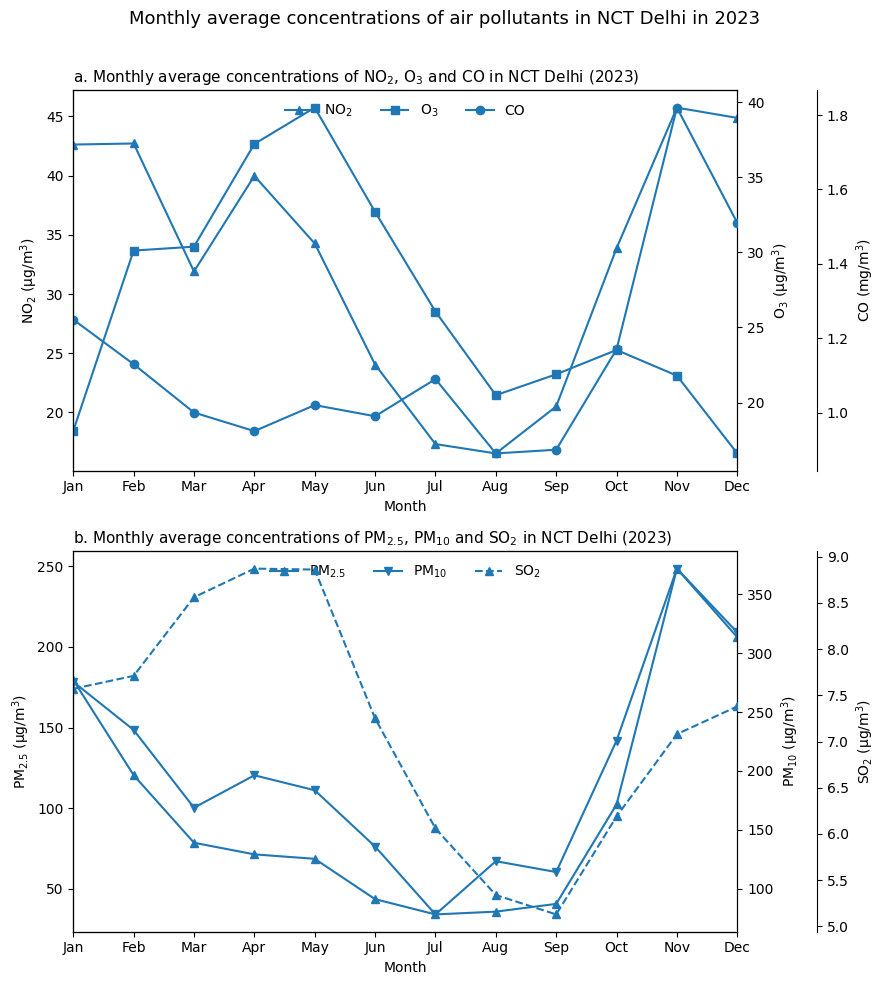

Saved monthly table: /content/drive/MyDrive/Classic UHI/Monthly_Average_Air_Pollutants_NCT_Delhi_2023.csv
Saved file check: /content/drive/MyDrive/Classic UHI/File_Check_Monthly_Air_Pollutants_2023.csv
Saved figure: /content/drive/MyDrive/Classic UHI/Monthly_Air_Pollutants_NCT_Delhi_2023.png

PROCESSING YEAR: 2024
TERI Gram, Gurugram -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H.csv
Dr Karni Singh Shooting Range, Delhi -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H.csv
Sri Aurobindo Marg -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H.csv
Narela -> raw_data_hourly_narela,_delhi_-_dpcc_1H.csv
Najafgarh -> raw_data_hourly_najafgarh,_delhi_-_dpcc_1H.csv
Alipur -> raw_data_hourly_alipur,_delhi_-_dpcc_1H.csv
Bawana -> raw_data_hourly_bawana,_delhi_-_dpcc_1H.csv
Vivek Vihar, Delhi -> raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H.csv
Punjabi Bagh, Delhi -> raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H.csv
Rohini, Delhi -> raw_data_hourly_rohini,_delhi_-_dpcc_1H.c

,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,1,1.42,52.03,17.02,206.19,311.30,8.62
1,2,1.11,49.91,33.02,107.09,201.02,11.31
2,3,0.95,46.55,37.24,80.43,180.36,15.37
3,4,0.88,47.10,48.52,69.38,196.51,17.63
4,5,1.11,45.03,62.87,90.28,243.70,19.26
5,6,0.96,30.45,49.53,56.85,191.87,13.95
6,7,0.91,26.62,30.25,40.98,91.60,8.49
7,8,0.89,23.71,21.01,28.38,63.91,10.23
8,9,0.94,26.63,23.96,42.04,93.36,8.79
9,10,1.44,47.68,41.79,115.18,225.67,11.74


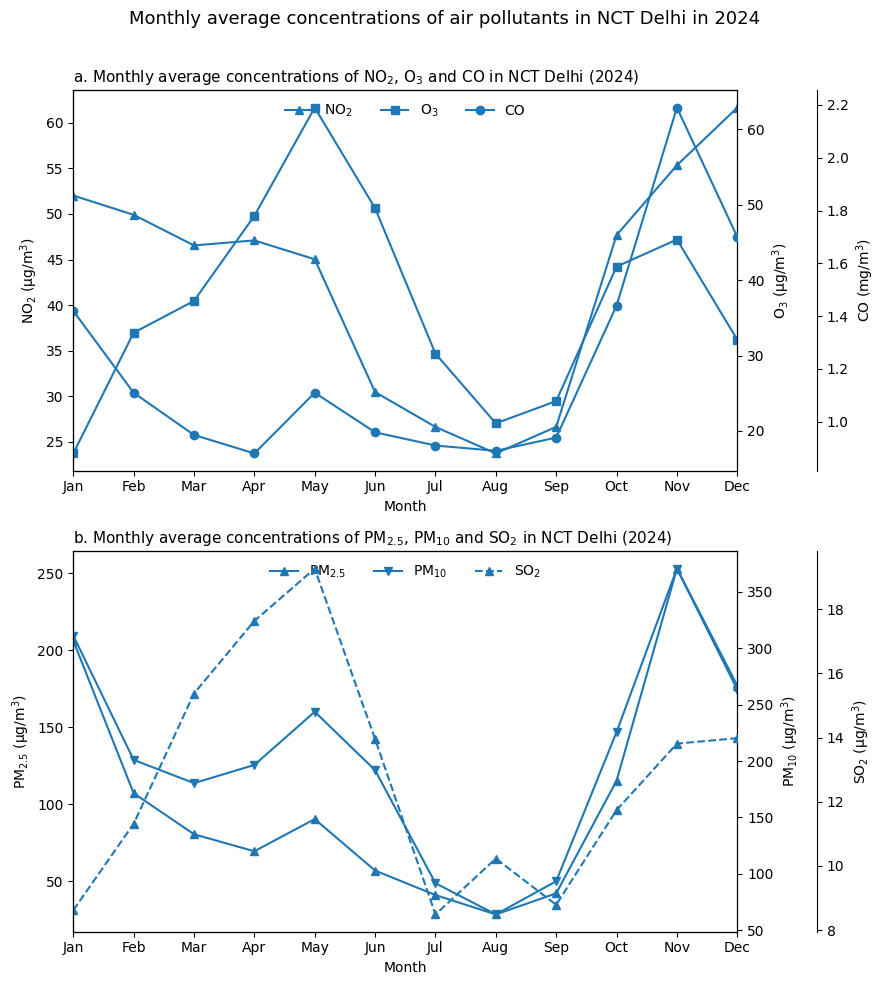

Saved monthly table: /content/drive/MyDrive/Classic UHI/Monthly_Average_Air_Pollutants_NCT_Delhi_2024.csv
Saved file check: /content/drive/MyDrive/Classic UHI/File_Check_Monthly_Air_Pollutants_2024.csv
Saved figure: /content/drive/MyDrive/Classic UHI/Monthly_Air_Pollutants_NCT_Delhi_2024.png

Done.


In [6]:


# ============================================================
# MONTHLY AIR POLLUTANT PLOTS FOR NCT DELHI
# Years: 2023 and 2024
# All 13 stations together
# Save:
#   1) Monthly_Air_Pollutants_NCT_Delhi_2023.png
#   2) Monthly_Air_Pollutants_NCT_Delhi_2024.png
# Also save monthly tables as CSV for checking
# ============================================================

# ---------- paths ----------
base_path = Path("/content")
drive_output = Path("/content/drive/MyDrive/Classic UHI")
output_path = drive_output if drive_output.exists() else base_path
print("Output path:", output_path)

# ---------- pollutants ----------
pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

# ---------- final 13 stations ----------
stations = {
    "TERI Gram, Gurugram": ["teri", "gram"],
    "Dr Karni Singh Shooting Range, Delhi": ["karni", "shooting"],
    "Sri Aurobindo Marg": ["aurobindo"],
    "Narela": ["narela"],
    "Najafgarh": ["najafgarh"],
    "Alipur": ["alipur"],
    "Bawana": ["bawana"],
    "Vivek Vihar, Delhi": ["vivek", "vihar"],
    "Punjabi Bagh, Delhi": ["punjabi", "bagh"],
    "Rohini, Delhi": ["rohini"],
    "Wazirpur, Delhi": ["wazirpur"],
    "ITO, New Delhi": ["ito"],
    "Mandir Marg, New Delhi": ["mandir", "marg"]
}


def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

def find_station_files(search_terms):
    all_csvs = list(base_path.glob("*.csv"))


    all_csvs = [
        f for f in all_csvs
        if "missingness" not in f.name.lower()
        and "average" not in f.name.lower()
        and "yearly" not in f.name.lower()
        and "monthly_air_pollutants" not in f.name.lower()
        and "table_" not in f.name.lower()
        and "file_check" not in f.name.lower()
    ]

    matched_files = []
    for f in all_csvs:
        fname = f.name.lower()
        if all(term.lower() in fname for term in search_terms) and "1h" in fname:
            matched_files.append(f)

    year_file_map = {}
    for f in matched_files:
        year = detect_year_from_filename(f.name)
        year_file_map[year] = f

    return year_file_map

def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace("μ", "µ")
    name = name.replace("ug", "µg")
    name = name.replace("m3", "m³")
    name = name.replace(" ", "")
    return name

def get_column_map(df):
    normalized_columns = {normalize_name(col): col for col in df.columns}

    required_map = {
        "CO (mg/m³)": ["co(mg/m³)"],
        "NO2 (µg/m³)": ["no2(µg/m³)"],
        "Ozone (µg/m³)": ["ozone(µg/m³)", "o3(µg/m³)"],
        "PM2.5 (µg/m³)": ["pm2.5(µg/m³)", "pm25(µg/m³)"],
        "PM10 (µg/m³)": ["pm10(µg/m³)"],
        "SO2 (µg/m³)": ["so2(µg/m³)"]
    }

    column_map = {}
    for clean_name, possible_names in required_map.items():
        found_col = None
        for possible in possible_names:
            possible_norm = normalize_name(possible)
            if possible_norm in normalized_columns:
                found_col = normalized_columns[possible_norm]
                break
        column_map[clean_name] = found_col

    return column_map

def get_station_monthly_means(file_path, year):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Timestamp" not in df.columns:
        raise ValueError(f"Timestamp column not found in {file_path.name}")

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).copy()
    df = df[df["Timestamp"].dt.year == year].copy()

    column_map = get_column_map(df)

    df_use = pd.DataFrame()
    df_use["Timestamp"] = df["Timestamp"]

    for clean_col in pollutants:
        original_col = column_map[clean_col]
        if original_col is None:
            print(f"WARNING: {clean_col} not found in {file_path.name}")
            df_use[clean_col] = pd.NA
        else:
            df_use[clean_col] = pd.to_numeric(df[original_col], errors="coerce")

    df_use["Month"] = df_use["Timestamp"].dt.month

    monthly_means = (
        df_use.groupby("Month")[pollutants]
        .mean()
        .round(2)
        .reset_index()
    )

    return monthly_means

def month_labels():
    return ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def make_yrd_style_plot(monthly_df, year, save_path):
    months = monthly_df["Month"].tolist()
    labels = month_labels()

    fig, axes = plt.subplots(2, 1, figsize=(9, 10))

    # ---------------- panel a: NO2, O3, CO ----------------
    ax1 = axes[0]
    ax1b = ax1.twinx()
    ax1c = ax1.twinx()
    ax1c.spines["right"].set_position(("axes", 1.12))

    l1 = ax1.plot(months, monthly_df["NO2 (µg/m³)"], marker="^", label="NO$_2$")
    l2 = ax1b.plot(months, monthly_df["Ozone (µg/m³)"], marker="s", label="O$_3$")
    l3 = ax1c.plot(months, monthly_df["CO (mg/m³)"], marker="o", label="CO")

    ax1.set_xlim(1, 12)
    ax1.set_xticks(months)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel("Month")
    ax1.set_ylabel("NO$_2$ (µg/m$^3$)")
    ax1b.set_ylabel("O$_3$ (µg/m$^3$)")
    ax1c.set_ylabel("CO (mg/m$^3$)")
    ax1.set_title(f"a. Monthly average concentrations of NO$_2$, O$_3$ and CO in NCT Delhi ({year})", loc="left", fontsize=11)

    lines = l1 + l2 + l3
    labels_combined = [line.get_label() for line in lines]
    ax1.legend(lines, labels_combined, loc="upper center", ncol=3, frameon=False)

    # ---------------- panel b: PM2.5, PM10, SO2 ----------------
    ax2 = axes[1]
    ax2b = ax2.twinx()
    ax2c = ax2.twinx()
    ax2c.spines["right"].set_position(("axes", 1.12))

    l4 = ax2.plot(months, monthly_df["PM2.5 (µg/m³)"], marker="^", label="PM$_{2.5}$")
    l5 = ax2b.plot(months, monthly_df["PM10 (µg/m³)"], marker="v", label="PM$_{10}$")
    l6 = ax2c.plot(months, monthly_df["SO2 (µg/m³)"], marker="^", linestyle="--", label="SO$_2$")

    ax2.set_xlim(1, 12)
    ax2.set_xticks(months)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel("Month")
    ax2.set_ylabel("PM$_{2.5}$ (µg/m$^3$)")
    ax2b.set_ylabel("PM$_{10}$ (µg/m$^3$)")
    ax2c.set_ylabel("SO$_2$ (µg/m$^3$)")
    ax2.set_title(f"b. Monthly average concentrations of PM$_{{2.5}}$, PM$_{{10}}$ and SO$_2$ in NCT Delhi ({year})", loc="left", fontsize=11)

    lines2 = l4 + l5 + l6
    labels_combined2 = [line.get_label() for line in lines2]
    ax2.legend(lines2, labels_combined2, loc="upper center", ncol=3, frameon=False)

    fig.suptitle(f"Monthly average concentrations of air pollutants in NCT Delhi in {year}", fontsize=13, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



all_monthly_outputs = {}

for target_year in [2023, 2024]:
    print("\n" + "=" * 110)
    print("PROCESSING YEAR:", target_year)

    station_monthly_list = []
    file_check_rows = []

    for station_name, search_terms in stations.items():
        station_files = find_station_files(search_terms)

        if target_year not in station_files:
            print(f"WARNING: File missing for {station_name}, {target_year}")
            file_check_rows.append({
                "Station": station_name,
                "Year": target_year,
                "File": "MISSING"
            })
            continue

        file_path = station_files[target_year]
        print(station_name, "->", file_path.name)

        monthly_means = get_station_monthly_means(file_path, target_year)
        monthly_means["Station"] = station_name
        station_monthly_list.append(monthly_means)

        file_check_rows.append({
            "Station": station_name,
            "Year": target_year,
            "File": file_path.name
        })

    if len(station_monthly_list) == 0:
        print(f"ERROR: No station files found for {target_year}")
        continue

    # Equal-weight monthly average across stations
    all_station_monthly = pd.concat(station_monthly_list, ignore_index=True)

    monthly_nct = (
        all_station_monthly.groupby("Month")[pollutants]
        .mean()
        .round(2)
        .reset_index()
    )

    all_monthly_outputs[target_year] = monthly_nct

    print("\nMONTHLY TABLE FOR", target_year)
    display(monthly_nct)

    # Save monthly table
    table_save = output_path / f"Monthly_Average_Air_Pollutants_NCT_Delhi_{target_year}.csv"
    monthly_nct.to_csv(table_save, index=False)

    # Save file-check table
    file_check_table = pd.DataFrame(file_check_rows)
    check_save = output_path / f"File_Check_Monthly_Air_Pollutants_{target_year}.csv"
    file_check_table.to_csv(check_save, index=False)

    # Plot and save figure
    fig_save = output_path / f"Monthly_Air_Pollutants_NCT_Delhi_{target_year}.png"
    make_yrd_style_plot(monthly_nct, target_year, fig_save)

    print("Saved monthly table:", table_save)
    print("Saved file check:", check_save)
    print("Saved figure:", fig_save)

print("\nDone.")

In [7]:

# ============================================================
# Average across 13 stations
# For later merge with nighttime SUHI
# ============================================================

base_path = Path("/content")
target_year = 2023

pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

stations = {
    "TERI Gram, Gurugram": ["teri", "gram"],
    "Dr Karni Singh Shooting Range, Delhi": ["karni", "shooting"],
    "Sri Aurobindo Marg": ["aurobindo"],
    "Narela": ["narela"],
    "Najafgarh": ["najafgarh"],
    "Alipur": ["alipur"],
    "Bawana": ["bawana"],
    "Vivek Vihar, Delhi": ["vivek", "vihar"],
    "Punjabi Bagh, Delhi": ["punjabi", "bagh"],
    "Rohini, Delhi": ["rohini"],
    "Wazirpur, Delhi": ["wazirpur"],
    "ITO, New Delhi": ["ito"],
    "Mandir Marg, New Delhi": ["mandir", "marg"]
}

def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

def find_station_files(search_terms):
    all_csvs = list(base_path.glob("*.csv"))

    # Avoid generated output files
    all_csvs = [
        f for f in all_csvs
        if "missingness" not in f.name.lower()
        and "average" not in f.name.lower()
        and "yearly" not in f.name.lower()
        and "monthly_air_pollutants" not in f.name.lower()
        and "table_" not in f.name.lower()
        and "file_check" not in f.name.lower()
        and "merged" not in f.name.lower()
        and "correlation" not in f.name.lower()
    ]

    matched_files = []

    for f in all_csvs:
        fname = f.name.lower()

        if all(term.lower() in fname for term in search_terms) and "1h" in fname:
            matched_files.append(f)

    year_file_map = {}

    for f in matched_files:
        year = detect_year_from_filename(f.name)
        year_file_map[year] = f

    return year_file_map

def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace("μ", "µ")
    name = name.replace("ug", "µg")
    name = name.replace("m3", "m³")
    name = name.replace(" ", "")
    return name

def get_column_map(df):
    normalized_columns = {normalize_name(col): col for col in df.columns}

    required_map = {
        "CO (mg/m³)": ["co(mg/m³)"],
        "NO2 (µg/m³)": ["no2(µg/m³)"],
        "Ozone (µg/m³)": ["ozone(µg/m³)", "o3(µg/m³)"],
        "PM2.5 (µg/m³)": ["pm2.5(µg/m³)", "pm25(µg/m³)"],
        "PM10 (µg/m³)": ["pm10(µg/m³)"],
        "SO2 (µg/m³)": ["so2(µg/m³)"]
    }

    column_map = {}

    for clean_name, possible_names in required_map.items():
        found_col = None

        for possible in possible_names:
            possible_norm = normalize_name(possible)

            if possible_norm in normalized_columns:
                found_col = normalized_columns[possible_norm]
                break

        column_map[clean_name] = found_col

    return column_map

def get_station_monthly_means(file_path, year, station_name):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Timestamp" not in df.columns:
        raise ValueError(f"Timestamp column not found in {file_path.name}")

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).copy()
    df = df[df["Timestamp"].dt.year == year].copy()

    column_map = get_column_map(df)

    df_use = pd.DataFrame()
    df_use["Timestamp"] = df["Timestamp"]

    for clean_col in pollutants:
        original_col = column_map[clean_col]

        if original_col is None:
            print(f"WARNING: {clean_col} not found in {file_path.name}")
            df_use[clean_col] = pd.NA
        else:
            df_use[clean_col] = pd.to_numeric(df[original_col], errors="coerce")

    df_use["Month"] = df_use["Timestamp"].dt.month
    df_use["Station"] = station_name

    monthly_means = (
        df_use
        .groupby(["Station", "Month"])[pollutants]
        .mean()
        .round(2)
        .reset_index()
    )

    return monthly_means, len(df_use)



station_monthly_list = []
file_check_rows = []

print("=" * 100)
print("PROCESSING MONTHLY AIR POLLUTION DATA FOR:", target_year)

for station_name, search_terms in stations.items():

    station_files = find_station_files(search_terms)

    if target_year not in station_files:
        print(f"WARNING: File missing for {station_name}, {target_year}")

        file_check_rows.append({
            "Station": station_name,
            "Year": target_year,
            "File": "MISSING",
            "Rows used": 0
        })

        continue

    file_path = station_files[target_year]

    print(station_name, "->", file_path.name)

    monthly_means, rows_used = get_station_monthly_means(
        file_path=file_path,
        year=target_year,
        station_name=station_name
    )

    station_monthly_list.append(monthly_means)

    file_check_rows.append({
        "Station": station_name,
        "Year": target_year,
        "File": file_path.name,
        "Rows used": rows_used
    })

# Station-wise monthly table
stationwise_monthly_2023 = pd.concat(station_monthly_list, ignore_index=True)

monthly_pollution_2023 = (
    stationwise_monthly_2023
    .groupby("Month")[pollutants]
    .mean()
    .round(2)
    .reset_index()
)

monthly_pollution_2023.insert(0, "Year", target_year)

file_check_2023 = pd.DataFrame(file_check_rows)

print("\n" + "=" * 100)
print("FINAL 2023 MONTHLY POLLUTION TABLE: Average across 13 stations")
display(monthly_pollution_2023)

print("\n" + "=" * 100)
print("FILE CHECK TABLE")
display(file_check_2023)

print("\n" + "=" * 100)
print("STATION-WISE MONTHLY TABLE FOR CHECKING")
display(stationwise_monthly_2023)

# Save outputs
output_monthly = base_path / "Monthly_Pollution_Average_13Stations_2023.csv"
output_stationwise = base_path / "Stationwise_Monthly_Pollution_2023.csv"
output_check = base_path / "File_Check_Pollution_2023.csv"

monthly_pollution_2023.to_csv(output_monthly, index=False)
stationwise_monthly_2023.to_csv(output_stationwise, index=False)
file_check_2023.to_csv(output_check, index=False)

print("\nSaved files:")
print(output_monthly)
print(output_stationwise)
print(output_check)

PROCESSING MONTHLY AIR POLLUTION DATA FOR: 2023
TERI Gram, Gurugram -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H (1).csv
Dr Karni Singh Shooting Range, Delhi -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H (1).csv
Sri Aurobindo Marg -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H (1).csv
Narela -> raw_data_hourly_narela,_delhi_-_dpcc_1H (1).csv
Najafgarh -> raw_data_hourly_najafgarh,_delhi_-_dpcc_1H (1).csv
Alipur -> raw_data_hourly_alipur,_delhi_-_dpcc_1H (1).csv
Bawana -> raw_data_hourly_bawana,_delhi_-_dpcc_1H (1).csv
Vivek Vihar, Delhi -> raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H (1).csv
Punjabi Bagh, Delhi -> raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H (1).csv
Rohini, Delhi -> raw_data_hourly_rohini,_delhi_-_dpcc_1H (1).csv
Wazirpur, Delhi -> raw_data_hourly_wazirpur,_delhi_-_dpcc_1H (1).csv
ITO, New Delhi -> raw_data_hourly_ito,_delhi_-_cpcb_1H (1).csv
Mandir Marg, New Delhi -> raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H (1).csv

FINAL 2023 MO

,Year,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2023,1,1.25,42.63,18.11,179.48,275.70,7.57
1,2023,2,1.13,42.72,30.12,120.52,234.80,7.71
2,2023,3,1.00,31.91,30.38,78.66,168.72,8.56
3,2023,4,0.95,39.98,37.22,71.45,196.26,8.87
4,2023,5,1.02,34.27,39.64,68.69,183.54,8.86
5,2023,6,0.99,24.04,32.70,43.69,135.75,7.25
6,2023,7,1.09,17.32,26.06,34.24,78.04,6.06
7,2023,8,0.89,16.53,20.49,35.97,123.27,5.34
8,2023,9,0.90,20.50,21.88,40.77,114.06,5.13
9,2023,10,1.17,33.87,23.50,102.36,225.70,6.19



FILE CHECK TABLE


,Station,Year,File,Rows used
0,"TERI Gram, Gurugram",2023,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8760
1,"Dr Karni Singh Shooting Range, Delhi",2023,raw_data_hourly_dr._karni_singh_shooting_range...,8760
2,Sri Aurobindo Marg,2023,"raw_data_hourly_sri_aurobindo_marg,_delhi_-_dp...",8760
3,Narela,2023,"raw_data_hourly_narela,_delhi_-_dpcc_1H (1).csv",8760
4,Najafgarh,2023,"raw_data_hourly_najafgarh,_delhi_-_dpcc_1H (1)...",8760
5,Alipur,2023,"raw_data_hourly_alipur,_delhi_-_dpcc_1H (1).csv",8760
6,Bawana,2023,"raw_data_hourly_bawana,_delhi_-_dpcc_1H (1).csv",8760
7,"Vivek Vihar, Delhi",2023,"raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H (...",8760
8,"Punjabi Bagh, Delhi",2023,"raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H ...",8760
9,"Rohini, Delhi",2023,"raw_data_hourly_rohini,_delhi_-_dpcc_1H (1).csv",8760



STATION-WISE MONTHLY TABLE FOR CHECKING


,Station,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,"TERI Gram, Gurugram",1,0.97,15.23,10.00,139.69,270.58,9.62
1,"TERI Gram, Gurugram",2,0.71,8.97,16.91,115.90,253.90,8.47
2,"TERI Gram, Gurugram",3,0.56,9.58,26.24,69.88,158.58,7.61
3,"TERI Gram, Gurugram",4,0.51,10.35,28.78,88.77,207.12,6.26
4,"TERI Gram, Gurugram",5,0.44,10.40,28.20,71.32,205.43,7.79
...,...,...,...,...,...,...,...,...
151,"Mandir Marg, New Delhi",8,0.86,40.79,22.42,29.96,114.57,9.55
152,"Mandir Marg, New Delhi",9,0.67,30.58,14.10,35.90,93.37,6.42
153,"Mandir Marg, New Delhi",10,0.73,26.29,17.57,93.09,185.98,3.51
154,"Mandir Marg, New Delhi",11,1.34,50.06,13.28,232.47,321.54,3.09



Saved files:
/content/Monthly_Pollution_Average_13Stations_2023.csv
/content/Stationwise_Monthly_Pollution_2023.csv
/content/File_Check_Pollution_2023.csv


In [8]:


# ============================================================
# Average across 13 stations
# For later merge with nighttime SUHI
# ============================================================

base_path = Path("/content")
target_year = 2024

pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

stations = {
    "TERI Gram, Gurugram": ["teri", "gram"],
    "Dr Karni Singh Shooting Range, Delhi": ["karni", "shooting"],
    "Sri Aurobindo Marg": ["aurobindo"],
    "Narela": ["narela"],
    "Najafgarh": ["najafgarh"],
    "Alipur": ["alipur"],
    "Bawana": ["bawana"],
    "Vivek Vihar, Delhi": ["vivek", "vihar"],
    "Punjabi Bagh, Delhi": ["punjabi", "bagh"],
    "Rohini, Delhi": ["rohini"],
    "Wazirpur, Delhi": ["wazirpur"],
    "ITO, New Delhi": ["ito"],
    "Mandir Marg, New Delhi": ["mandir", "marg"]
}

def detect_year_from_filename(filename):
    if "(4)" in filename:
        return 2020
    elif "(3)" in filename:
        return 2021
    elif "(2)" in filename:
        return 2022
    elif "(1)" in filename:
        return 2023
    else:
        return 2024

def find_station_files(search_terms):
    all_csvs = list(base_path.glob("*.csv"))

    all_csvs = [
        f for f in all_csvs
        if "missingness" not in f.name.lower()
        and "average" not in f.name.lower()
        and "yearly" not in f.name.lower()
        and "monthly_air_pollutants" not in f.name.lower()
        and "table_" not in f.name.lower()
        and "file_check" not in f.name.lower()
        and "merged" not in f.name.lower()
        and "correlation" not in f.name.lower()
    ]

    matched_files = []

    for f in all_csvs:
        fname = f.name.lower()

        if all(term.lower() in fname for term in search_terms) and "1h" in fname:
            matched_files.append(f)

    year_file_map = {}

    for f in matched_files:
        year = detect_year_from_filename(f.name)
        year_file_map[year] = f

    return year_file_map

def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace("μ", "µ")
    name = name.replace("ug", "µg")
    name = name.replace("m3", "m³")
    name = name.replace(" ", "")
    return name

def get_column_map(df):
    normalized_columns = {normalize_name(col): col for col in df.columns}

    required_map = {
        "CO (mg/m³)": ["co(mg/m³)"],
        "NO2 (µg/m³)": ["no2(µg/m³)"],
        "Ozone (µg/m³)": ["ozone(µg/m³)", "o3(µg/m³)"],
        "PM2.5 (µg/m³)": ["pm2.5(µg/m³)", "pm25(µg/m³)"],
        "PM10 (µg/m³)": ["pm10(µg/m³)"],
        "SO2 (µg/m³)": ["so2(µg/m³)"]
    }

    column_map = {}

    for clean_name, possible_names in required_map.items():
        found_col = None

        for possible in possible_names:
            possible_norm = normalize_name(possible)

            if possible_norm in normalized_columns:
                found_col = normalized_columns[possible_norm]
                break

        column_map[clean_name] = found_col

    return column_map

def get_station_monthly_means(file_path, year, station_name):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Timestamp" not in df.columns:
        raise ValueError(f"Timestamp column not found in {file_path.name}")

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).copy()
    df = df[df["Timestamp"].dt.year == year].copy()

    column_map = get_column_map(df)

    df_use = pd.DataFrame()
    df_use["Timestamp"] = df["Timestamp"]

    for clean_col in pollutants:
        original_col = column_map[clean_col]

        if original_col is None:
            print(f"WARNING: {clean_col} not found in {file_path.name}")
            df_use[clean_col] = pd.NA
        else:
            df_use[clean_col] = pd.to_numeric(df[original_col], errors="coerce")

    df_use["Month"] = df_use["Timestamp"].dt.month
    df_use["Station"] = station_name

    monthly_means = (
        df_use
        .groupby(["Station", "Month"])[pollutants]
        .mean()
        .round(2)
        .reset_index()
    )

    return monthly_means, len(df_use)


station_monthly_list = []
file_check_rows = []

print("=" * 100)
print("PROCESSING MONTHLY AIR POLLUTION DATA FOR:", target_year)

for station_name, search_terms in stations.items():

    station_files = find_station_files(search_terms)

    if target_year not in station_files:
        print(f"WARNING: File missing for {station_name}, {target_year}")

        file_check_rows.append({
            "Station": station_name,
            "Year": target_year,
            "File": "MISSING",
            "Rows used": 0
        })

        continue

    file_path = station_files[target_year]

    print(station_name, "->", file_path.name)

    monthly_means, rows_used = get_station_monthly_means(
        file_path=file_path,
        year=target_year,
        station_name=station_name
    )

    station_monthly_list.append(monthly_means)

    file_check_rows.append({
        "Station": station_name,
        "Year": target_year,
        "File": file_path.name,
        "Rows used": rows_used
    })

stationwise_monthly_2024 = pd.concat(station_monthly_list, ignore_index=True)

monthly_pollution_2024 = (
    stationwise_monthly_2024
    .groupby("Month")[pollutants]
    .mean()
    .round(2)
    .reset_index()
)

monthly_pollution_2024.insert(0, "Year", target_year)

file_check_2024 = pd.DataFrame(file_check_rows)

print("\n" + "=" * 100)
print("FINAL 2024 MONTHLY POLLUTION TABLE: Average across 13 stations")
display(monthly_pollution_2024)

print("\n" + "=" * 100)
print("FILE CHECK TABLE")
display(file_check_2024)

print("\n" + "=" * 100)
print("STATION-WISE MONTHLY TABLE FOR CHECKING")
display(stationwise_monthly_2024)

# Save outputs
output_monthly = base_path / "Monthly_Pollution_Average_13Stations_2024.csv"
output_stationwise = base_path / "Stationwise_Monthly_Pollution_2024.csv"
output_check = base_path / "File_Check_Pollution_2024.csv"

monthly_pollution_2024.to_csv(output_monthly, index=False)
stationwise_monthly_2024.to_csv(output_stationwise, index=False)
file_check_2024.to_csv(output_check, index=False)

print("\nSaved files:")
print(output_monthly)
print(output_stationwise)
print(output_check)

PROCESSING MONTHLY AIR POLLUTION DATA FOR: 2024
TERI Gram, Gurugram -> raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H.csv
Dr Karni Singh Shooting Range, Delhi -> raw_data_hourly_dr._karni_singh_shooting_range,_delhi_-_dpcc_1H.csv
Sri Aurobindo Marg -> raw_data_hourly_sri_aurobindo_marg,_delhi_-_dpcc_1H.csv
Narela -> raw_data_hourly_narela,_delhi_-_dpcc_1H.csv
Najafgarh -> raw_data_hourly_najafgarh,_delhi_-_dpcc_1H.csv
Alipur -> raw_data_hourly_alipur,_delhi_-_dpcc_1H.csv
Bawana -> raw_data_hourly_bawana,_delhi_-_dpcc_1H.csv
Vivek Vihar, Delhi -> raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H.csv
Punjabi Bagh, Delhi -> raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H.csv
Rohini, Delhi -> raw_data_hourly_rohini,_delhi_-_dpcc_1H.csv
Wazirpur, Delhi -> raw_data_hourly_wazirpur,_delhi_-_dpcc_1H.csv
ITO, New Delhi -> raw_data_hourly_ito,_delhi_-_cpcb_1H.csv
Mandir Marg, New Delhi -> raw_data_hourly_mandir_marg,_delhi_-_dpcc_1H.csv

FINAL 2024 MONTHLY POLLUTION TABLE: Average across 13 stations


,Year,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2024,1,1.42,52.03,17.02,206.19,311.30,8.62
1,2024,2,1.11,49.91,33.02,107.09,201.02,11.31
2,2024,3,0.95,46.55,37.24,80.43,180.36,15.37
3,2024,4,0.88,47.10,48.52,69.38,196.51,17.63
4,2024,5,1.11,45.03,62.87,90.28,243.70,19.26
5,2024,6,0.96,30.45,49.53,56.85,191.87,13.95
6,2024,7,0.91,26.62,30.25,40.98,91.60,8.49
7,2024,8,0.89,23.71,21.01,28.38,63.91,10.23
8,2024,9,0.94,26.63,23.96,42.04,93.36,8.79
9,2024,10,1.44,47.68,41.79,115.18,225.67,11.74



FILE CHECK TABLE


,Station,Year,File,Rows used
0,"TERI Gram, Gurugram",2024,"raw_data_hourly_teri_gram,_gurugram_-_hspcb_1H...",8784
1,"Dr Karni Singh Shooting Range, Delhi",2024,raw_data_hourly_dr._karni_singh_shooting_range...,8784
2,Sri Aurobindo Marg,2024,"raw_data_hourly_sri_aurobindo_marg,_delhi_-_dp...",8784
3,Narela,2024,"raw_data_hourly_narela,_delhi_-_dpcc_1H.csv",8784
4,Najafgarh,2024,"raw_data_hourly_najafgarh,_delhi_-_dpcc_1H.csv",8784
5,Alipur,2024,"raw_data_hourly_alipur,_delhi_-_dpcc_1H.csv",8784
6,Bawana,2024,"raw_data_hourly_bawana,_delhi_-_dpcc_1H.csv",8784
7,"Vivek Vihar, Delhi",2024,"raw_data_hourly_vivek_vihar,_delhi_-_dpcc_1H.csv",8784
8,"Punjabi Bagh, Delhi",2024,"raw_data_hourly_punjabi_bagh,_delhi_-_dpcc_1H.csv",8784
9,"Rohini, Delhi",2024,"raw_data_hourly_rohini,_delhi_-_dpcc_1H.csv",8784



STATION-WISE MONTHLY TABLE FOR CHECKING


,Station,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,"TERI Gram, Gurugram",1,1.08,31.40,18.05,126.38,227.62,3.84
1,"TERI Gram, Gurugram",2,0.66,29.95,10.47,97.66,250.41,3.28
2,"TERI Gram, Gurugram",3,0.50,30.83,21.27,95.76,260.27,3.13
3,"TERI Gram, Gurugram",4,0.48,33.16,35.35,92.31,260.96,3.59
4,"TERI Gram, Gurugram",5,0.67,31.60,50.58,119.80,237.09,4.56
...,...,...,...,...,...,...,...,...
151,"Mandir Marg, New Delhi",8,0.71,36.23,8.66,26.01,50.54,5.70
152,"Mandir Marg, New Delhi",9,0.84,37.96,17.24,41.79,68.93,7.16
153,"Mandir Marg, New Delhi",10,1.01,59.53,32.61,109.70,163.88,6.18
154,"Mandir Marg, New Delhi",11,1.48,72.68,30.17,243.91,305.47,7.28



Saved files:
/content/Monthly_Pollution_Average_13Stations_2024.csv
/content/Stationwise_Monthly_Pollution_2024.csv
/content/File_Check_Pollution_2024.csv


In [9]:


# ============================================================
# MODIS LST + SUHI + AIR POLLUTANTS
# ============================================================

base_path = Path("/content")
drive_path = Path("/content/drive/MyDrive/Classic UHI")

target_year = 2023

modis_file = drive_path / "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
pollution_file = base_path / "Monthly_Pollution_Average_13Stations_2023.csv"



modis_df = pd.read_csv(modis_file)
modis_df.columns = modis_df.columns.str.strip()

print("MODIS columns:")
print(list(modis_df.columns))

modis_df = modis_df[
    [
        "year",
        "month",
        "region",
        "mean_LST_Day_C",
        "mean_LST_Night_C"
    ]
].copy()


modis_2023 = modis_df[modis_df["year"] == target_year].copy()



modis_pivot = modis_2023.pivot_table(
    index=["year", "month"],
    columns="region",
    values=["mean_LST_Day_C", "mean_LST_Night_C"],
    aggfunc="mean"
)

# Flatten column names
modis_pivot.columns = [
    f"{value}_{region}" for value, region in modis_pivot.columns
]

modis_pivot = modis_pivot.reset_index()



modis_pivot["Daytime LST (°C)"] = modis_pivot["mean_LST_Day_C_Urban"]
modis_pivot["Nighttime LST (°C)"] = modis_pivot["mean_LST_Night_C_Urban"]

modis_pivot["Daytime Reference LST (°C)"] = modis_pivot["mean_LST_Day_C_Reference_1km"]
modis_pivot["Nighttime Reference LST (°C)"] = modis_pivot["mean_LST_Night_C_Reference_1km"]

modis_pivot["Daytime SUHI (°C)"] = (
    modis_pivot["Daytime LST (°C)"] -
    modis_pivot["Daytime Reference LST (°C)"]
)

modis_pivot["Nighttime SUHI (°C)"] = (
    modis_pivot["Nighttime LST (°C)"] -
    modis_pivot["Nighttime Reference LST (°C)"]
)

suhi_2023 = modis_pivot[
    [
        "year",
        "month",
        "Daytime LST (°C)",
        "Daytime Reference LST (°C)",
        "Daytime SUHI (°C)",
        "Nighttime LST (°C)",
        "Nighttime Reference LST (°C)",
        "Nighttime SUHI (°C)"
    ]
].copy()

suhi_2023 = suhi_2023.rename(columns={
    "year": "Year",
    "month": "Month"
})

suhi_2023 = suhi_2023.round(2)

print("\n2023 MODIS LST and SUHI table:")
display(suhi_2023)



monthly_pollution_2023 = pd.read_csv(pollution_file)

monthly_pollution_2023["Year"] = monthly_pollution_2023["Year"].astype(int)
monthly_pollution_2023["Month"] = monthly_pollution_2023["Month"].astype(int)

print("\n2023 monthly pollution table:")
display(monthly_pollution_2023)



merged_2023 = pd.merge(
    suhi_2023,
    monthly_pollution_2023,
    on=["Year", "Month"],
    how="inner"
)

merged_2023 = merged_2023.round(2)

print("\nFINAL MERGED 2023 TABLE: LST + SUHI + POLLUTANTS")
display(merged_2023)



output_file = base_path / "Merged_LST_SUHI_Pollution_2023.csv"
merged_2023.to_csv(output_file, index=False)

print("\nSaved:", output_file)

MODIS columns:
['system:index', 'mean_LST_Day_C', 'mean_LST_Night_C', 'modis_image_count', 'month', 'region', 'year', '.geo']

2023 MODIS LST and SUHI table:


,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C)
0,2023.0,1.0,20.25,19.45,0.80,9.32,6.77,2.56
1,2023.0,2.0,27.70,26.23,1.47,16.50,15.41,1.09
2,2023.0,3.0,32.81,31.27,1.54,19.38,17.17,2.21
3,2023.0,4.0,37.96,37.46,0.50,22.57,19.24,3.33
4,2023.0,5.0,38.07,37.68,0.39,23.78,20.77,3.01
5,2023.0,6.0,37.63,37.13,0.50,25.85,23.96,1.88
6,2023.0,7.0,36.32,34.04,2.28,25.99,25.14,0.85
7,2023.0,8.0,33.06,31.86,1.20,25.09,23.48,1.61
8,2023.0,9.0,35.30,34.02,1.28,25.67,24.29,1.38
9,2023.0,10.0,32.70,32.28,0.42,21.62,18.10,3.51



2023 monthly pollution table:


,Year,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2023,1,1.25,42.63,18.11,179.48,275.70,7.57
1,2023,2,1.13,42.72,30.12,120.52,234.80,7.71
2,2023,3,1.00,31.91,30.38,78.66,168.72,8.56
3,2023,4,0.95,39.98,37.22,71.45,196.26,8.87
4,2023,5,1.02,34.27,39.64,68.69,183.54,8.86
5,2023,6,0.99,24.04,32.70,43.69,135.75,7.25
6,2023,7,1.09,17.32,26.06,34.24,78.04,6.06
7,2023,8,0.89,16.53,20.49,35.97,123.27,5.34
8,2023,9,0.90,20.50,21.88,40.77,114.06,5.13
9,2023,10,1.17,33.87,23.50,102.36,225.70,6.19



FINAL MERGED 2023 TABLE: LST + SUHI + POLLUTANTS


,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2023.0,1.0,20.25,19.45,0.80,9.32,6.77,2.56,1.25,42.63,18.11,179.48,275.70,7.57
1,2023.0,2.0,27.70,26.23,1.47,16.50,15.41,1.09,1.13,42.72,30.12,120.52,234.80,7.71
2,2023.0,3.0,32.81,31.27,1.54,19.38,17.17,2.21,1.00,31.91,30.38,78.66,168.72,8.56
3,2023.0,4.0,37.96,37.46,0.50,22.57,19.24,3.33,0.95,39.98,37.22,71.45,196.26,8.87
4,2023.0,5.0,38.07,37.68,0.39,23.78,20.77,3.01,1.02,34.27,39.64,68.69,183.54,8.86
5,2023.0,6.0,37.63,37.13,0.50,25.85,23.96,1.88,0.99,24.04,32.70,43.69,135.75,7.25
6,2023.0,7.0,36.32,34.04,2.28,25.99,25.14,0.85,1.09,17.32,26.06,34.24,78.04,6.06
7,2023.0,8.0,33.06,31.86,1.20,25.09,23.48,1.61,0.89,16.53,20.49,35.97,123.27,5.34
8,2023.0,9.0,35.30,34.02,1.28,25.67,24.29,1.38,0.90,20.50,21.88,40.77,114.06,5.13
9,2023.0,10.0,32.70,32.28,0.42,21.62,18.10,3.51,1.17,33.87,23.50,102.36,225.70,6.19



Saved: /content/Merged_LST_SUHI_Pollution_2023.csv


,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³),Month_Name
0,2023.0,1.0,20.25,19.45,0.80,9.32,6.77,2.56,1.25,42.63,18.11,179.48,275.70,7.57,Jan
1,2023.0,2.0,27.70,26.23,1.47,16.50,15.41,1.09,1.13,42.72,30.12,120.52,234.80,7.71,Feb
2,2023.0,3.0,32.81,31.27,1.54,19.38,17.17,2.21,1.00,31.91,30.38,78.66,168.72,8.56,Mar
3,2023.0,4.0,37.96,37.46,0.50,22.57,19.24,3.33,0.95,39.98,37.22,71.45,196.26,8.87,Apr
4,2023.0,5.0,38.07,37.68,0.39,23.78,20.77,3.01,1.02,34.27,39.64,68.69,183.54,8.86,May
5,2023.0,6.0,37.63,37.13,0.50,25.85,23.96,1.88,0.99,24.04,32.70,43.69,135.75,7.25,Jun
6,2023.0,7.0,36.32,34.04,2.28,25.99,25.14,0.85,1.09,17.32,26.06,34.24,78.04,6.06,Jul
7,2023.0,8.0,33.06,31.86,1.20,25.09,23.48,1.61,0.89,16.53,20.49,35.97,123.27,5.34,Aug
8,2023.0,9.0,35.30,34.02,1.28,25.67,24.29,1.38,0.90,20.50,21.88,40.77,114.06,5.13,Sep
9,2023.0,10.0,32.70,32.28,0.42,21.62,18.10,3.51,1.17,33.87,23.50,102.36,225.70,6.19,Oct


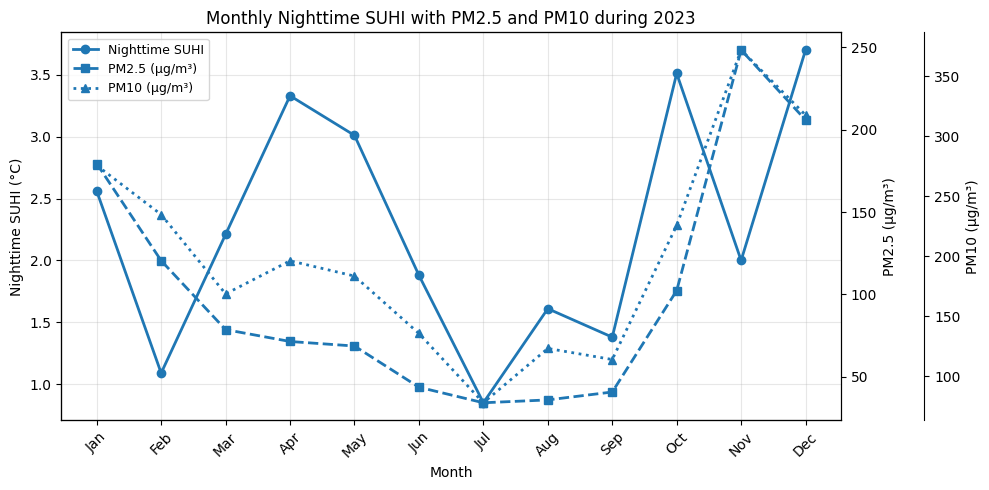

Saved: /content/Nighttime_SUHI_PM25_PM10_2023.png


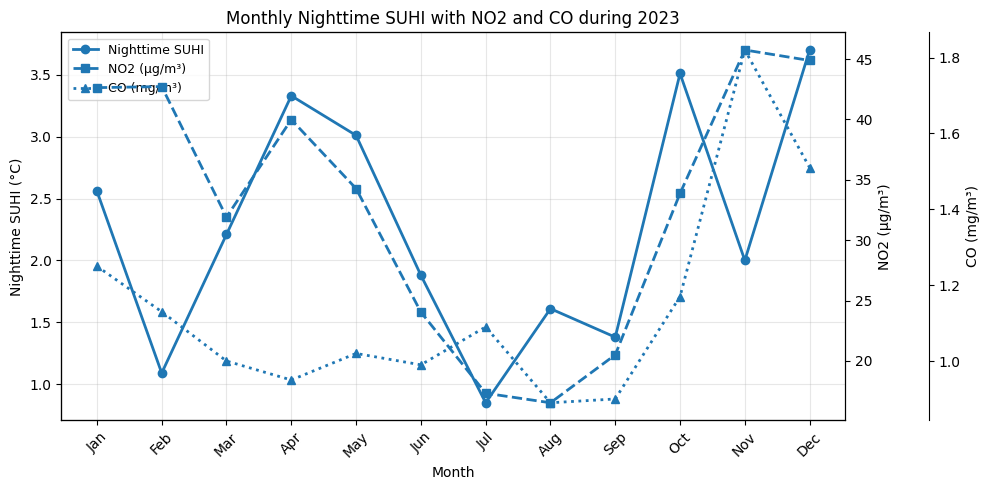

Saved: /content/Nighttime_SUHI_NO2_CO_2023.png


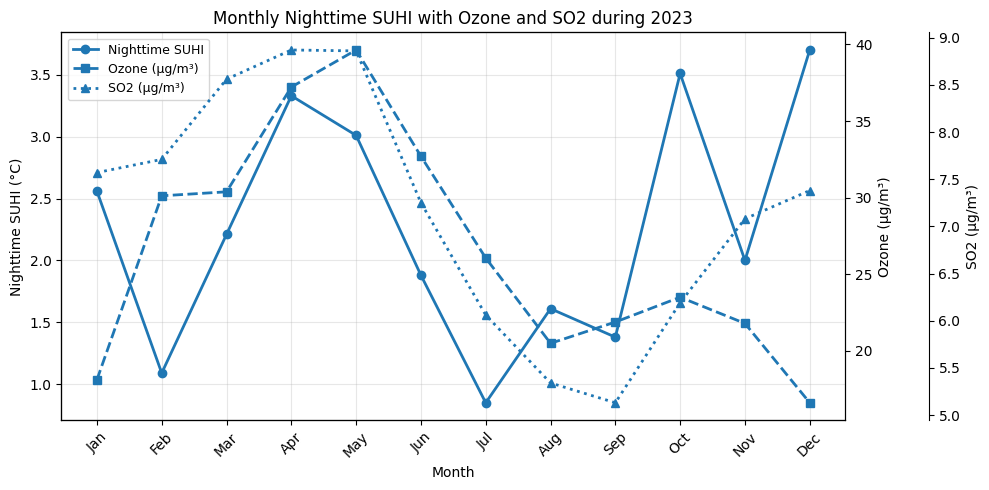

Saved: /content/Nighttime_SUHI_Ozone_SO2_2023.png


In [10]:


# ============================================================
# Triple-scale plots: Nighttime SUHI + two pollutants
# ============================================================

base_path = Path("/content")

merged_file = base_path / "Merged_LST_SUHI_Pollution_2023.csv"

df = pd.read_csv(merged_file)


month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df["Month_Name"] = df["Month"].map(month_names)

display(df)



def plot_triple_scale(df, pollutant_1, pollutant_2, title, output_name):

    fig, ax1 = plt.subplots(figsize=(10, 5))


    ax1.plot(
        df["Month_Name"],
        df["Nighttime SUHI (°C)"],
        marker="o",
        linewidth=2,
        label="Nighttime SUHI"
    )

    ax1.set_xlabel("Month")
    ax1.set_ylabel("Nighttime SUHI (°C)")
    ax1.tick_params(axis="x", rotation=45)


    ax2 = ax1.twinx()

    ax2.plot(
        df["Month_Name"],
        df[pollutant_1],
        marker="s",
        linewidth=2,
        linestyle="--",
        label=pollutant_1
    )

    ax2.set_ylabel(pollutant_1)

    ax3 = ax1.twinx()

    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        df["Month_Name"],
        df[pollutant_2],
        marker="^",
        linewidth=2,
        linestyle=":",
        label=pollutant_2
    )

    ax3.set_ylabel(pollutant_2)

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2 + lines_3,
        labels_1 + labels_2 + labels_3,
        loc="upper left",
        fontsize=9
    )

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()

    output_path = base_path / output_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


# ------------------------------------------------------------
# Plot 1: Nighttime SUHI with particulate pollutants
# ------------------------------------------------------------

plot_triple_scale(
    df=df,
    pollutant_1="PM2.5 (µg/m³)",
    pollutant_2="PM10 (µg/m³)",
    title="Monthly Nighttime SUHI with PM2.5 and PM10 during 2023",
    output_name="Nighttime_SUHI_PM25_PM10_2023.png"
)


# ------------------------------------------------------------
# Plot 2: Nighttime SUHI with combustion-related gaseous pollutants
# ------------------------------------------------------------

plot_triple_scale(
    df=df,
    pollutant_1="NO2 (µg/m³)",
    pollutant_2="CO (mg/m³)",
    title="Monthly Nighttime SUHI with NO2 and CO during 2023",
    output_name="Nighttime_SUHI_NO2_CO_2023.png"
)


# ------------------------------------------------------------
# Plot 3: Nighttime SUHI with Ozone and SO2
# ------------------------------------------------------------

plot_triple_scale(
    df=df,
    pollutant_1="Ozone (µg/m³)",
    pollutant_2="SO2 (µg/m³)",
    title="Monthly Nighttime SUHI with Ozone and SO2 during 2023",
    output_name="Nighttime_SUHI_Ozone_SO2_2023.png"
)

,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³),Month_Name
0,2023.0,1.0,20.25,19.45,0.80,9.32,6.77,2.56,1.25,42.63,18.11,179.48,275.70,7.57,Jan
1,2023.0,2.0,27.70,26.23,1.47,16.50,15.41,1.09,1.13,42.72,30.12,120.52,234.80,7.71,Feb
2,2023.0,3.0,32.81,31.27,1.54,19.38,17.17,2.21,1.00,31.91,30.38,78.66,168.72,8.56,Mar
3,2023.0,4.0,37.96,37.46,0.50,22.57,19.24,3.33,0.95,39.98,37.22,71.45,196.26,8.87,Apr
4,2023.0,5.0,38.07,37.68,0.39,23.78,20.77,3.01,1.02,34.27,39.64,68.69,183.54,8.86,May
5,2023.0,6.0,37.63,37.13,0.50,25.85,23.96,1.88,0.99,24.04,32.70,43.69,135.75,7.25,Jun
6,2023.0,7.0,36.32,34.04,2.28,25.99,25.14,0.85,1.09,17.32,26.06,34.24,78.04,6.06,Jul
7,2023.0,8.0,33.06,31.86,1.20,25.09,23.48,1.61,0.89,16.53,20.49,35.97,123.27,5.34,Aug
8,2023.0,9.0,35.30,34.02,1.28,25.67,24.29,1.38,0.90,20.50,21.88,40.77,114.06,5.13,Sep
9,2023.0,10.0,32.70,32.28,0.42,21.62,18.10,3.51,1.17,33.87,23.50,102.36,225.70,6.19,Oct


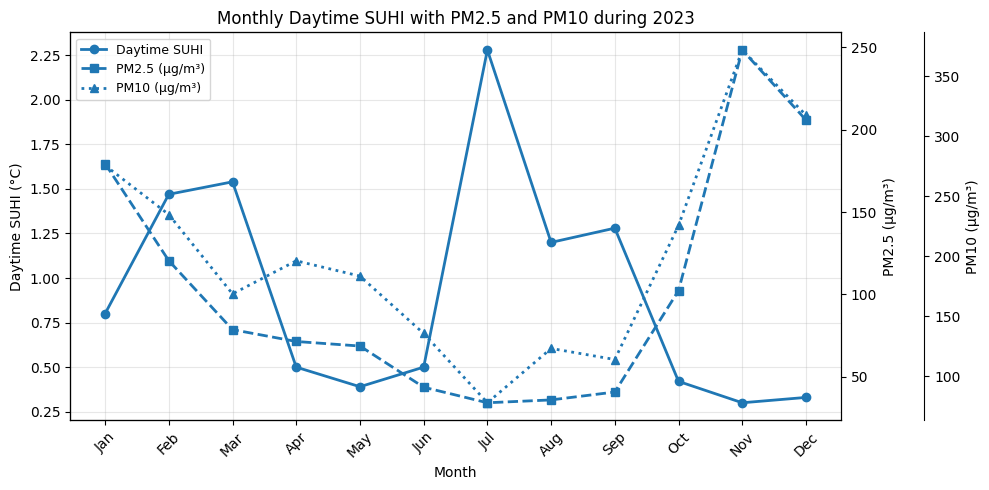

Saved: /content/Daytime_SUHI_PM25_PM10_2023.png


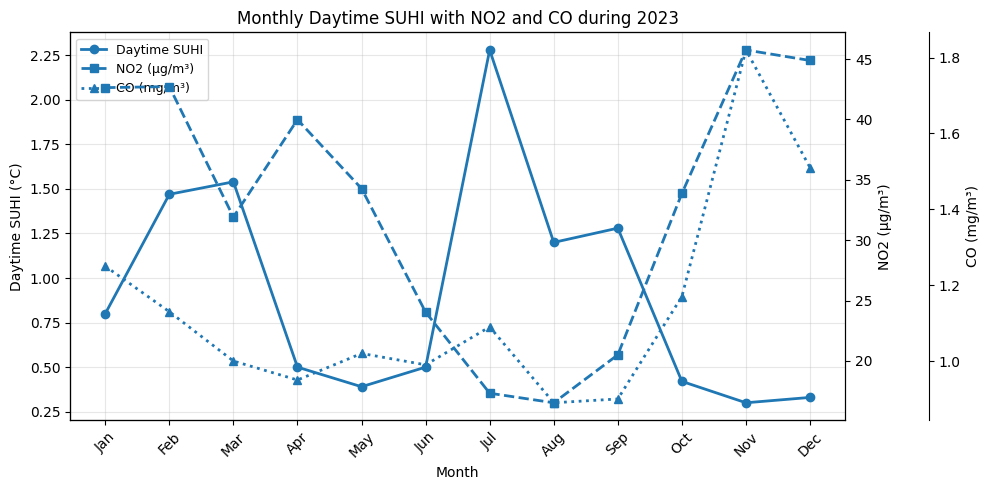

Saved: /content/Daytime_SUHI_NO2_CO_2023.png


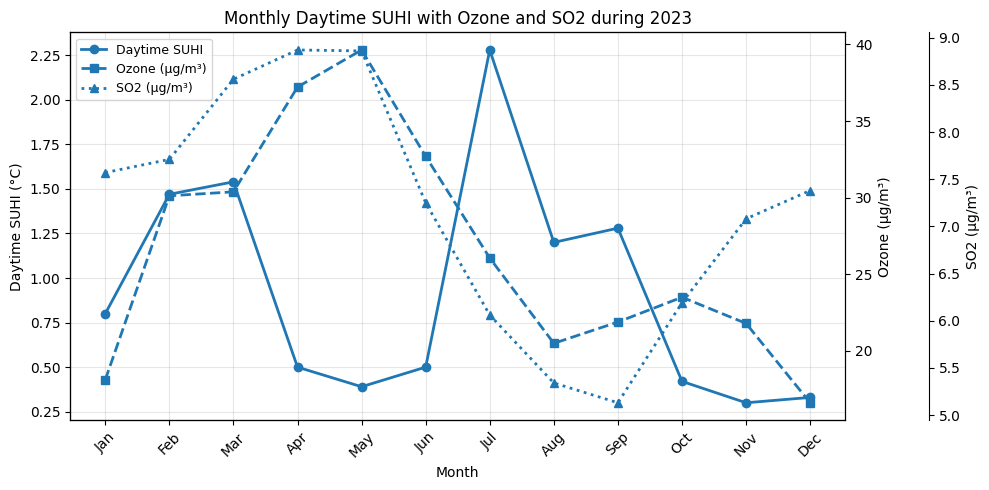

Saved: /content/Daytime_SUHI_Ozone_SO2_2023.png


In [11]:

# ============================================================
# Triple-scale plots: Daytime SUHI + two pollutants
# ============================================================

base_path = Path("/content")

merged_file = base_path / "Merged_LST_SUHI_Pollution_2023.csv"

df = pd.read_csv(merged_file)

# Month labels
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df["Month_Name"] = df["Month"].map(month_names)

display(df)


def plot_triple_scale_daytime(df, pollutant_1, pollutant_2, title, output_name):

    fig, ax1 = plt.subplots(figsize=(10, 5))


    ax1.plot(
        df["Month_Name"],
        df["Daytime SUHI (°C)"],
        marker="o",
        linewidth=2,
        label="Daytime SUHI"
    )

    ax1.set_xlabel("Month")
    ax1.set_ylabel("Daytime SUHI (°C)")
    ax1.tick_params(axis="x", rotation=45)


    ax2 = ax1.twinx()

    ax2.plot(
        df["Month_Name"],
        df[pollutant_1],
        marker="s",
        linewidth=2,
        linestyle="--",
        label=pollutant_1
    )

    ax2.set_ylabel(pollutant_1)


    ax3 = ax1.twinx()

    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        df["Month_Name"],
        df[pollutant_2],
        marker="^",
        linewidth=2,
        linestyle=":",
        label=pollutant_2
    )

    ax3.set_ylabel(pollutant_2)

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2 + lines_3,
        labels_1 + labels_2 + labels_3,
        loc="upper left",
        fontsize=9
    )

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()

    output_path = base_path / output_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


# ------------------------------------------------------------
# Plot 1: Daytime SUHI with particulate pollutants
# ------------------------------------------------------------

plot_triple_scale_daytime(
    df=df,
    pollutant_1="PM2.5 (µg/m³)",
    pollutant_2="PM10 (µg/m³)",
    title="Monthly Daytime SUHI with PM2.5 and PM10 during 2023",
    output_name="Daytime_SUHI_PM25_PM10_2023.png"
)


# ------------------------------------------------------------
# Plot 2: Daytime SUHI with combustion-related gaseous pollutants
# ------------------------------------------------------------

plot_triple_scale_daytime(
    df=df,
    pollutant_1="NO2 (µg/m³)",
    pollutant_2="CO (mg/m³)",
    title="Monthly Daytime SUHI with NO2 and CO during 2023",
    output_name="Daytime_SUHI_NO2_CO_2023.png"
)


# ------------------------------------------------------------
# Plot 3: Daytime SUHI with Ozone and SO2
# ------------------------------------------------------------

plot_triple_scale_daytime(
    df=df,
    pollutant_1="Ozone (µg/m³)",
    pollutant_2="SO2 (µg/m³)",
    title="Monthly Daytime SUHI with Ozone and SO2 during 2023",
    output_name="Daytime_SUHI_Ozone_SO2_2023.png"
)

In [12]:


# ============================================================
# Main focus: Nighttime SUHI
# Supporting: Daytime SUHI
# ============================================================

base_path = Path("/content")

merged_file = base_path / "Merged_LST_SUHI_Pollution_2023.csv"

df = pd.read_csv(merged_file)

pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

suhi_columns = [
    "Nighttime SUHI (°C)",
    "Daytime SUHI (°C)"
]

correlation_rows = []

for pollutant in pollutants:

    row = {
        "Pollutant": pollutant
    }

    for suhi_col in suhi_columns:

        temp = df[[suhi_col, pollutant]].dropna()

        if len(temp) >= 3:
            r_value, p_value = pearsonr(temp[suhi_col], temp[pollutant])
        else:
            r_value, p_value = None, None

        if suhi_col == "Nighttime SUHI (°C)":
            row["Nighttime SUHI r"] = r_value
            row["Nighttime SUHI p-value"] = p_value

        elif suhi_col == "Daytime SUHI (°C)":
            row["Daytime SUHI r"] = r_value
            row["Daytime SUHI p-value"] = p_value

    correlation_rows.append(row)

correlation_2023 = pd.DataFrame(correlation_rows)

correlation_2023 = correlation_2023[
    [
        "Pollutant",
        "Nighttime SUHI r",
        "Nighttime SUHI p-value",
        "Daytime SUHI r",
        "Daytime SUHI p-value"
    ]
]

correlation_2023 = correlation_2023.round(3)

print("2023 SUHI vs pollutant correlation table")
display(correlation_2023)


output_file = base_path / "SUHI_Pollutant_Correlation_2023.csv"
correlation_2023.to_csv(output_file, index=False)

print("\nSaved:", output_file)

2023 SUHI vs pollutant correlation table


,Pollutant,Nighttime SUHI r,Nighttime SUHI p-value,Daytime SUHI r,Daytime SUHI p-value
0,CO (mg/m³),0.225,0.482,-0.409,0.187
1,NO2 (µg/m³),0.540,0.070,-0.559,0.059
2,Ozone (µg/m³),0.049,0.880,-0.046,0.888
3,PM2.5 (µg/m³),0.355,0.257,-0.487,0.109
4,PM10 (µg/m³),0.480,0.114,-0.624,0.030
5,SO2 (µg/m³),0.453,0.139,-0.324,0.304



Saved: /content/SUHI_Pollutant_Correlation_2023.csv


2024 MODIS LST and SUHI table:


,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C)
0,2024.0,1.0,19.40,19.17,0.23,8.90,7.00,1.90
1,2024.0,2.0,24.81,23.61,1.20,12.75,10.13,2.62
2,2024.0,3.0,32.60,31.33,1.28,19.62,16.78,2.84
3,2024.0,4.0,38.49,38.69,-0.20,23.71,19.88,3.83
4,2024.0,5.0,41.24,41.84,-0.59,29.15,27.42,1.73
5,2024.0,6.0,41.68,42.09,-0.41,28.38,26.50,1.88
6,2024.0,7.0,35.66,34.90,0.76,26.73,26.03,0.71
7,2024.0,8.0,32.05,30.54,1.52,25.84,24.94,0.90
8,2024.0,9.0,32.75,31.40,1.36,25.01,23.27,1.74
9,2024.0,10.0,32.59,32.01,0.59,22.95,18.99,3.96



2024 monthly pollution table:


,Year,Month,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2024,1,1.42,52.03,17.02,206.19,311.30,8.62
1,2024,2,1.11,49.91,33.02,107.09,201.02,11.31
2,2024,3,0.95,46.55,37.24,80.43,180.36,15.37
3,2024,4,0.88,47.10,48.52,69.38,196.51,17.63
4,2024,5,1.11,45.03,62.87,90.28,243.70,19.26
5,2024,6,0.96,30.45,49.53,56.85,191.87,13.95
6,2024,7,0.91,26.62,30.25,40.98,91.60,8.49
7,2024,8,0.89,23.71,21.01,28.38,63.91,10.23
8,2024,9,0.94,26.63,23.96,42.04,93.36,8.79
9,2024,10,1.44,47.68,41.79,115.18,225.67,11.74



FINAL MERGED 2024 TABLE: LST + SUHI + POLLUTANTS


,Year,Month,Daytime LST (°C),Daytime Reference LST (°C),Daytime SUHI (°C),Nighttime LST (°C),Nighttime Reference LST (°C),Nighttime SUHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2024.0,1.0,19.40,19.17,0.23,8.90,7.00,1.90,1.42,52.03,17.02,206.19,311.30,8.62
1,2024.0,2.0,24.81,23.61,1.20,12.75,10.13,2.62,1.11,49.91,33.02,107.09,201.02,11.31
2,2024.0,3.0,32.60,31.33,1.28,19.62,16.78,2.84,0.95,46.55,37.24,80.43,180.36,15.37
3,2024.0,4.0,38.49,38.69,-0.20,23.71,19.88,3.83,0.88,47.10,48.52,69.38,196.51,17.63
4,2024.0,5.0,41.24,41.84,-0.59,29.15,27.42,1.73,1.11,45.03,62.87,90.28,243.70,19.26
5,2024.0,6.0,41.68,42.09,-0.41,28.38,26.50,1.88,0.96,30.45,49.53,56.85,191.87,13.95
6,2024.0,7.0,35.66,34.90,0.76,26.73,26.03,0.71,0.91,26.62,30.25,40.98,91.60,8.49
7,2024.0,8.0,32.05,30.54,1.52,25.84,24.94,0.90,0.89,23.71,21.01,28.38,63.91,10.23
8,2024.0,9.0,32.75,31.40,1.36,25.01,23.27,1.74,0.94,26.63,23.96,42.04,93.36,8.79
9,2024.0,10.0,32.59,32.01,0.59,22.95,18.99,3.96,1.44,47.68,41.79,115.18,225.67,11.74



Saved: /content/Merged_LST_SUHI_Pollution_2024.csv


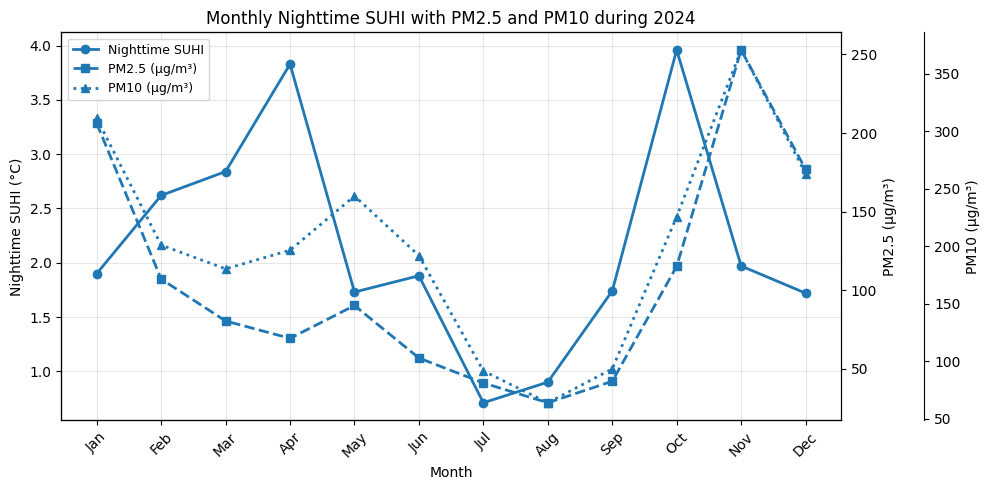

Saved: /content/Nighttime_SUHI_PM25_PM10_2024.png


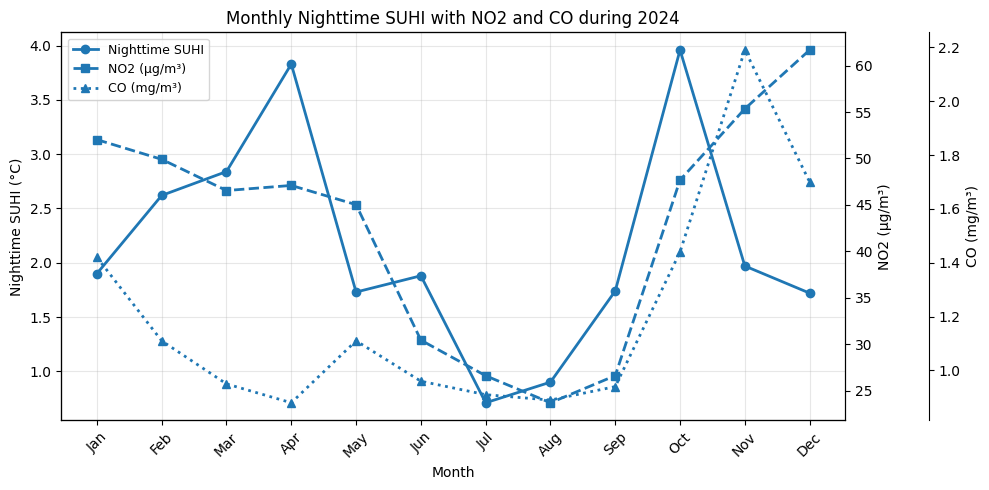

Saved: /content/Nighttime_SUHI_NO2_CO_2024.png


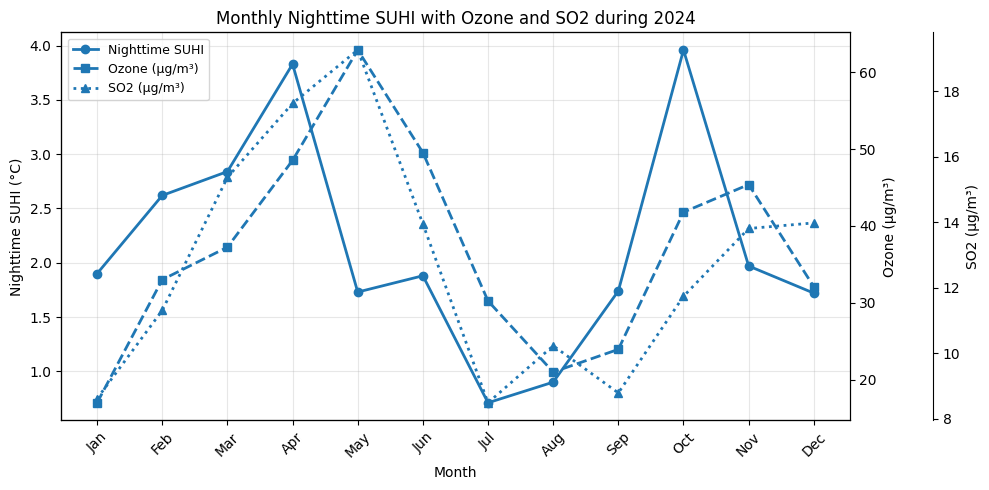

Saved: /content/Nighttime_SUHI_Ozone_SO2_2024.png


In [13]:


# ============================================================
# 1. Calculate 2024 SUHI from MODIS file
# 2. Merge with 2024 monthly pollutants
# 3. Plot Nighttime SUHI with pollutants using triple-scale plots
# ============================================================

base_path = Path("/content")
drive_path = Path("/content/drive/MyDrive/Classic UHI")

target_year = 2024

modis_file = drive_path / "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
pollution_file = base_path / "Monthly_Pollution_Average_13Stations_2024.csv"



modis_df = pd.read_csv(modis_file)
modis_df.columns = modis_df.columns.str.strip()

modis_df = modis_df[
    [
        "year",
        "month",
        "region",
        "mean_LST_Day_C",
        "mean_LST_Night_C"
    ]
].copy()

modis_2024 = modis_df[modis_df["year"] == target_year].copy()



modis_pivot = modis_2024.pivot_table(
    index=["year", "month"],
    columns="region",
    values=["mean_LST_Day_C", "mean_LST_Night_C"],
    aggfunc="mean"
)

modis_pivot.columns = [
    f"{value}_{region}" for value, region in modis_pivot.columns
]

modis_pivot = modis_pivot.reset_index()



modis_pivot["Daytime LST (°C)"] = modis_pivot["mean_LST_Day_C_Urban"]
modis_pivot["Nighttime LST (°C)"] = modis_pivot["mean_LST_Night_C_Urban"]

modis_pivot["Daytime Reference LST (°C)"] = modis_pivot["mean_LST_Day_C_Reference_1km"]
modis_pivot["Nighttime Reference LST (°C)"] = modis_pivot["mean_LST_Night_C_Reference_1km"]

modis_pivot["Daytime SUHI (°C)"] = (
    modis_pivot["Daytime LST (°C)"] -
    modis_pivot["Daytime Reference LST (°C)"]
)

modis_pivot["Nighttime SUHI (°C)"] = (
    modis_pivot["Nighttime LST (°C)"] -
    modis_pivot["Nighttime Reference LST (°C)"]
)

suhi_2024 = modis_pivot[
    [
        "year",
        "month",
        "Daytime LST (°C)",
        "Daytime Reference LST (°C)",
        "Daytime SUHI (°C)",
        "Nighttime LST (°C)",
        "Nighttime Reference LST (°C)",
        "Nighttime SUHI (°C)"
    ]
].copy()

suhi_2024 = suhi_2024.rename(columns={
    "year": "Year",
    "month": "Month"
})

suhi_2024 = suhi_2024.round(2)

print("2024 MODIS LST and SUHI table:")
display(suhi_2024)



monthly_pollution_2024 = pd.read_csv(pollution_file)

monthly_pollution_2024["Year"] = monthly_pollution_2024["Year"].astype(int)
monthly_pollution_2024["Month"] = monthly_pollution_2024["Month"].astype(int)

print("\n2024 monthly pollution table:")
display(monthly_pollution_2024)



merged_2024 = pd.merge(
    suhi_2024,
    monthly_pollution_2024,
    on=["Year", "Month"],
    how="inner"
)

merged_2024 = merged_2024.round(2)

print("\nFINAL MERGED 2024 TABLE: LST + SUHI + POLLUTANTS")
display(merged_2024)

output_csv = base_path / "Merged_LST_SUHI_Pollution_2024.csv"
merged_2024.to_csv(output_csv, index=False)

print("\nSaved:", output_csv)


month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

merged_2024["Month_Name"] = merged_2024["Month"].map(month_names)


def plot_triple_scale_nighttime_2024(df, pollutant_1, pollutant_2, title, output_name):

    fig, ax1 = plt.subplots(figsize=(10, 5))


    ax1.plot(
        df["Month_Name"],
        df["Nighttime SUHI (°C)"],
        marker="o",
        linewidth=2,
        label="Nighttime SUHI"
    )

    ax1.set_xlabel("Month")
    ax1.set_ylabel("Nighttime SUHI (°C)")
    ax1.tick_params(axis="x", rotation=45)


    ax2 = ax1.twinx()

    ax2.plot(
        df["Month_Name"],
        df[pollutant_1],
        marker="s",
        linewidth=2,
        linestyle="--",
        label=pollutant_1
    )

    ax2.set_ylabel(pollutant_1)

    ax3 = ax1.twinx()

    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        df["Month_Name"],
        df[pollutant_2],
        marker="^",
        linewidth=2,
        linestyle=":",
        label=pollutant_2
    )

    ax3.set_ylabel(pollutant_2)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2 + lines_3,
        labels_1 + labels_2 + labels_3,
        loc="upper left",
        fontsize=9
    )

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()

    output_path = base_path / output_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

# ------------------------------------------------------------
# 8. Plot 1: Nighttime SUHI with PM2.5 and PM10
# ------------------------------------------------------------

plot_triple_scale_nighttime_2024(
    df=merged_2024,
    pollutant_1="PM2.5 (µg/m³)",
    pollutant_2="PM10 (µg/m³)",
    title="Monthly Nighttime SUHI with PM2.5 and PM10 during 2024",
    output_name="Nighttime_SUHI_PM25_PM10_2024.png"
)

# ------------------------------------------------------------
# 9. Plot 2: Nighttime SUHI with NO2 and CO
# ------------------------------------------------------------

plot_triple_scale_nighttime_2024(
    df=merged_2024,
    pollutant_1="NO2 (µg/m³)",
    pollutant_2="CO (mg/m³)",
    title="Monthly Nighttime SUHI with NO2 and CO during 2024",
    output_name="Nighttime_SUHI_NO2_CO_2024.png"
)

# ------------------------------------------------------------
# 10. Plot 3: Nighttime SUHI with Ozone and SO2
# ------------------------------------------------------------

plot_triple_scale_nighttime_2024(
    df=merged_2024,
    pollutant_1="Ozone (µg/m³)",
    pollutant_2="SO2 (µg/m³)",
    title="Monthly Nighttime SUHI with Ozone and SO2 during 2024",
    output_name="Nighttime_SUHI_Ozone_SO2_2024.png"
)

In [14]:
import pandas as pd
from scipy.stats import pearsonr
from pathlib import Path
from IPython.display import display

# ============================================================
# 2024 SUHI vs POLLUTANTS CORRELATION
# Main focus: Nighttime SUHI
# Supporting: Daytime SUHI
# ============================================================

base_path = Path("/content")

merged_file = base_path / "Merged_LST_SUHI_Pollution_2024.csv"

df = pd.read_csv(merged_file)

pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

suhi_columns = [
    "Nighttime SUHI (°C)",
    "Daytime SUHI (°C)"
]

correlation_rows = []

for pollutant in pollutants:

    row = {
        "Pollutant": pollutant
    }

    for suhi_col in suhi_columns:

        temp = df[[suhi_col, pollutant]].dropna()

        if len(temp) >= 3:
            r_value, p_value = pearsonr(temp[suhi_col], temp[pollutant])
        else:
            r_value, p_value = None, None

        if suhi_col == "Nighttime SUHI (°C)":
            row["Nighttime SUHI r"] = r_value
            row["Nighttime SUHI p-value"] = p_value

        elif suhi_col == "Daytime SUHI (°C)":
            row["Daytime SUHI r"] = r_value
            row["Daytime SUHI p-value"] = p_value

    correlation_rows.append(row)

correlation_2024 = pd.DataFrame(correlation_rows)

correlation_2024 = correlation_2024[
    [
        "Pollutant",
        "Nighttime SUHI r",
        "Nighttime SUHI p-value",
        "Daytime SUHI r",
        "Daytime SUHI p-value"
    ]
]

correlation_2024 = correlation_2024.round(3)

print("2024 SUHI vs pollutant correlation table")
display(correlation_2024)


output_file = base_path / "SUHI_Pollutant_Correlation_2024.csv"
correlation_2024.to_csv(output_file, index=False)

print("\nSaved:", output_file)

2024 SUHI vs pollutant correlation table


,Pollutant,Nighttime SUHI r,Nighttime SUHI p-value,Daytime SUHI r,Daytime SUHI p-value
0,CO (mg/m³),0.055,0.865,-0.219,0.494
1,NO2 (µg/m³),0.469,0.124,-0.316,0.317
2,Ozone (µg/m³),0.357,0.255,-0.720,0.008
3,PM2.5 (µg/m³),0.118,0.716,-0.281,0.377
4,PM10 (µg/m³),0.295,0.352,-0.554,0.062
5,SO2 (µg/m³),0.400,0.197,-0.614,0.034



Saved: /content/SUHI_Pollutant_Correlation_2024.csv


In [15]:
import pandas as pd
from scipy.stats import pearsonr
from pathlib import Path
from IPython.display import display

# ============================================================
# POLLUTANT-TO-POLLUTANT CORRELATION ANALYSIS
# Years: 2023 and 2024
# Based on monthly average pollution values
# ============================================================

base_path = Path("/content")

pollutants = [
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

def pollutant_correlation_analysis(year):

    merged_file = base_path / f"Merged_LST_SUHI_Pollution_{year}.csv"

    if not merged_file.exists():
        raise FileNotFoundError(f"File not found: {merged_file}")

    df = pd.read_csv(merged_file)

    pollutant_df = df[pollutants].copy()



    r_matrix = pollutant_df.corr(method="pearson").round(3)



    p_matrix = pd.DataFrame(
        index=pollutants,
        columns=pollutants
    )

    for pollutant_1 in pollutants:
        for pollutant_2 in pollutants:

            temp = df[[pollutant_1, pollutant_2]].dropna()

            if pollutant_1 == pollutant_2:
                p_matrix.loc[pollutant_1, pollutant_2] = 0.000

            elif len(temp) >= 3:
                r_value, p_value = pearsonr(
                    temp[pollutant_1],
                    temp[pollutant_2]
                )
                p_matrix.loc[pollutant_1, pollutant_2] = round(p_value, 3)

            else:
                p_matrix.loc[pollutant_1, pollutant_2] = None


    print("=" * 100)
    print(f"{year} POLLUTANT-TO-POLLUTANT PEARSON r-VALUE MATRIX")
    display(r_matrix)

    print("=" * 100)
    print(f"{year} POLLUTANT-TO-POLLUTANT p-VALUE MATRIX")
    display(p_matrix)



    r_output = base_path / f"Pollutant_Correlation_r_Matrix_{year}.csv"
    p_output = base_path / f"Pollutant_Correlation_p_Matrix_{year}.csv"

    r_matrix.to_csv(r_output)
    p_matrix.to_csv(p_output)

    print("\nSaved:")
    print(r_output)
    print(p_output)

    return r_matrix, p_matrix


# r value matrix be used for correlation

r_2023, p_2023 = pollutant_correlation_analysis(2023)

r_2024, p_2024 = pollutant_correlation_analysis(2024)

2023 POLLUTANT-TO-POLLUTANT PEARSON r-VALUE MATRIX


,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
CO (mg/m³),1.000,0.671,-0.461,0.931,0.876,0.077
NO2 (µg/m³),0.671,1.000,-0.034,0.840,0.907,0.620
Ozone (µg/m³),-0.461,-0.034,1.000,-0.475,-0.337,0.642
PM2.5 (µg/m³),0.931,0.840,-0.475,1.000,0.972,0.222
PM10 (µg/m³),0.876,0.907,-0.337,0.972,1.000,0.327
SO2 (µg/m³),0.077,0.620,0.642,0.222,0.327,1.000


2023 POLLUTANT-TO-POLLUTANT p-VALUE MATRIX


,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
CO (mg/m³),0.0,0.017,0.131,0.0,0.0,0.812
NO2 (µg/m³),0.017,0.0,0.916,0.001,0.0,0.032
Ozone (µg/m³),0.131,0.916,0.0,0.119,0.283,0.024
PM2.5 (µg/m³),0.0,0.001,0.119,0.0,0.0,0.488
PM10 (µg/m³),0.0,0.0,0.283,0.0,0.0,0.3
SO2 (µg/m³),0.812,0.032,0.024,0.488,0.3,0.0



Saved:
/content/Pollutant_Correlation_r_Matrix_2023.csv
/content/Pollutant_Correlation_p_Matrix_2023.csv
2024 POLLUTANT-TO-POLLUTANT PEARSON r-VALUE MATRIX


,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
CO (mg/m³),1.000,0.703,0.070,0.929,0.830,0.038
NO2 (µg/m³),0.703,1.000,0.217,0.815,0.851,0.397
Ozone (µg/m³),0.070,0.217,1.000,-0.002,0.323,0.861
PM2.5 (µg/m³),0.929,0.815,-0.002,1.000,0.928,0.050
PM10 (µg/m³),0.830,0.851,0.323,0.928,1.000,0.342
SO2 (µg/m³),0.038,0.397,0.861,0.050,0.342,1.000


2024 POLLUTANT-TO-POLLUTANT p-VALUE MATRIX


,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
CO (mg/m³),0.0,0.011,0.829,0.0,0.001,0.907
NO2 (µg/m³),0.011,0.0,0.498,0.001,0.0,0.201
Ozone (µg/m³),0.829,0.498,0.0,0.996,0.305,0.0
PM2.5 (µg/m³),0.0,0.001,0.996,0.0,0.0,0.878
PM10 (µg/m³),0.001,0.0,0.305,0.0,0.0,0.276
SO2 (µg/m³),0.907,0.201,0.0,0.878,0.276,0.0



Saved:
/content/Pollutant_Correlation_r_Matrix_2024.csv
/content/Pollutant_Correlation_p_Matrix_2024.csv


In [16]:


base_path = Path("/content")
uhi_study_path = Path("/content/drive/MyDrive/UHI_study")
classic_path = Path("/content/drive/MyDrive/Classic UHI")

target_year = 2023



station_lst_file = uhi_study_path / "NDVI_LST_2023_station_buffers_monthly.csv"
reference_file = classic_path / "Classic_UHI_LST_NDVI_1km_Reference_2020_2024.csv"
pollution_file = base_path / "Stationwise_Monthly_Pollution_2023.csv"



station_lst = pd.read_csv(station_lst_file)
station_lst.columns = station_lst.columns.str.strip()

station_lst = station_lst[
    [
        "year",
        "month",
        "station_name",
        "group",
        "station_type",
        "LST_C",
        "NDVI"
    ]
].copy()

station_lst = station_lst[station_lst["year"] == target_year].copy()

station_lst = station_lst.rename(columns={
    "year": "Year",
    "month": "Month",
    "station_name": "Station",
    "group": "Group",
    "station_type": "Station Type",
    "LST_C": "Station LST (°C)"
})

station_lst["Month"] = station_lst["Month"].astype(int)



reference_df = pd.read_csv(reference_file)
reference_df.columns = reference_df.columns.str.strip()

print("Reference file columns:")
print(list(reference_df.columns))

reference_2023 = reference_df[reference_df["year"] == target_year].copy()



if "region" in reference_2023.columns:
    reference_2023 = reference_2023[
        reference_2023["region"].astype(str).str.lower().str.contains("reference")
    ].copy()


possible_ref_lst_cols = [
    "mean_LST_C",
    "mean_LST",
    "LST_C",
    "Reference_1km_LST_C",
    "reference_LST_C"
]

ref_lst_col = None
for col in possible_ref_lst_cols:
    if col in reference_2023.columns:
        ref_lst_col = col
        break

if ref_lst_col is None:
    raise ValueError(
        "Could not detect reference LST column. Check printed reference file columns above."
    )

reference_2023 = reference_2023[["year", "month", ref_lst_col]].copy()

reference_2023 = reference_2023.rename(columns={
    "year": "Year",
    "month": "Month",
    ref_lst_col: "Reference 1km LST (°C)"
})

reference_2023["Month"] = reference_2023["Month"].astype(int)



station_uhi = pd.merge(
    station_lst,
    reference_2023,
    on=["Year", "Month"],
    how="left"
)

station_uhi["Station UHI (°C)"] = (
    station_uhi["Station LST (°C)"] -
    station_uhi["Reference 1km LST (°C)"]
)



station_pollution = pd.read_csv(pollution_file)
station_pollution.columns = station_pollution.columns.str.strip()

station_pollution = station_pollution.rename(columns={
    "Station": "Station",
    "Month": "Month"
})

station_pollution["Month"] = station_pollution["Month"].astype(int)



def clean_station_name(name):
    name = str(name).strip().lower()
    name = name.replace(",", "")
    name = name.replace("-", " ")
    name = " ".join(name.split())
    return name

station_uhi["Station_clean"] = station_uhi["Station"].apply(clean_station_name)
station_pollution["Station_clean"] = station_pollution["Station"].apply(clean_station_name)



station_monthly_final_2023 = pd.merge(
    station_uhi,
    station_pollution,
    on=["Station_clean", "Month"],
    how="left",
    suffixes=("", "_pollution")
)

# Use clean station name from LST file
station_monthly_final_2023["Station"] = station_monthly_final_2023["Station"]



final_columns = [
    "Year",
    "Month",
    "Station",
    "Group",
    "Station Type",
    "Station LST (°C)",
    "Reference 1km LST (°C)",
    "Station UHI (°C)",
    "NDVI",
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

station_monthly_final_2023 = station_monthly_final_2023[final_columns].copy()

station_monthly_final_2023 = station_monthly_final_2023.round(2)


month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

station_monthly_final_2023.insert(
    2,
    "Month Name",
    station_monthly_final_2023["Month"].map(month_names)
)



print("=" * 100)
print("COMBINED STATION-WISE MONTHLY UHI + POLLUTION TABLE, 2023")
display(station_monthly_final_2023)

combined_output = base_path / "Stationwise_UHI_Pollution_2023_AllStations.csv"
station_monthly_final_2023.to_csv(combined_output, index=False)

print("\nSaved combined file:")
print(combined_output)



output_folder = base_path / "Stationwise_UHI_Pollution_2023_Tables"
output_folder.mkdir(exist_ok=True)

print("\n" + "=" * 100)
print("INDIVIDUAL STATION TABLES")

for station in sorted(station_monthly_final_2023["Station"].dropna().unique()):

    station_table = station_monthly_final_2023[
        station_monthly_final_2023["Station"] == station
    ].copy()

    station_table = station_table.sort_values("Month")

    print("\n" + "=" * 100)
    print(station)
    display(station_table)

    safe_name = (
        station.replace(",", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    output_file = output_folder / f"{safe_name}_UHI_Pollution_2023.csv"
    station_table.to_csv(output_file, index=False)

print("\nSaved individual station tables in:")
print(output_folder)

Reference file columns:
['system:index', 'landsat_image_count', 'mean_LST_C', 'mean_NDVI', 'month', 'region', 'year', '.geo']
COMBINED STATION-WISE MONTHLY UHI + POLLUTION TABLE, 2023


,Year,Month,Month Name,Station,Group,Station Type,Station LST (°C),Reference 1km LST (°C),Station UHI (°C),NDVI,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2023,1,Jan,Narela,rural_peripheral,peripheral_reference,18.56,17.44,1.13,0.31,1.09,40.51,26.74,180.98,278.59,10.79
1,2023,1,Jan,Najafgarh,rural_peripheral,rural_peripheral_reference,16.35,17.44,-1.09,0.62,0.90,12.60,17.61,130.31,181.62,1.44
2,2023,1,Jan,"Teri Gram, Gurugram",rural_peripheral,green_peripheral_reference,17.98,17.44,0.54,0.40,0.97,15.23,10.00,139.69,270.58,9.62
3,2023,1,Jan,Alipur,rural_peripheral,peripheral_reference,17.80,17.44,0.37,0.40,1.08,29.14,24.95,155.76,218.56,9.27
4,2023,1,Jan,Bawana,rural_peripheral,peripheral_industrial_reference,17.98,17.44,0.54,0.34,1.11,15.47,14.16,178.08,302.09,3.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,2023,12,Dec,Rohini Delhi,urban,northwest_urban,21.60,22.53,-0.94,0.34,1.89,34.19,13.61,232.53,365.99,3.73
152,2023,12,Dec,Wazirpur Delhi,urban,northwest_industrial_urban,21.53,22.53,-1.01,0.27,2.25,120.80,15.27,242.49,427.50,9.78
153,2023,12,Dec,Sri Aurobindo Marg,urban,south_urban_green,20.11,22.53,-2.42,0.50,1.24,30.96,10.57,184.36,267.28,10.40
154,2023,12,Dec,ITO New Delhi,urban,central_urban_traffic,21.48,22.53,-1.05,0.33,2.13,74.18,19.06,222.34,309.24,16.88



Saved combined file:
/content/Stationwise_UHI_Pollution_2023_AllStations.csv

INDIVIDUAL STATION TABLES

Alipur


,Year,Month,Month Name,Station,Group,Station Type,Station LST (°C),Reference 1km LST (°C),Station UHI (°C),NDVI,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
3,2023,1,Jan,Alipur,rural_peripheral,peripheral_reference,17.80,17.44,0.37,0.40,1.08,29.14,24.95,155.76,218.56,9.27
16,2023,2,Feb,Alipur,rural_peripheral,peripheral_reference,24.51,24.24,0.27,0.48,1.15,30.89,47.06,121.24,200.98,11.76
29,2023,3,Mar,Alipur,rural_peripheral,peripheral_reference,32.66,32.10,0.56,0.45,1.30,20.89,47.42,80.09,157.56,15.60
42,2023,4,Apr,Alipur,rural_peripheral,peripheral_reference,42.65,41.63,1.02,0.30,0.83,27.58,59.00,76.69,216.92,18.10
55,2023,5,May,Alipur,rural_peripheral,peripheral_reference,34.63,40.83,-6.20,0.31,1.03,27.34,58.69,67.45,185.65,12.94
68,2023,6,Jun,Alipur,rural_peripheral,peripheral_reference,44.75,44.03,0.72,0.31,1.63,20.25,32.73,44.41,128.26,8.23
81,2023,7,Jul,Alipur,rural_peripheral,peripheral_reference,37.76,37.70,0.06,0.43,1.46,13.79,27.07,32.34,59.34,5.46
94,2023,8,Aug,Alipur,rural_peripheral,peripheral_reference,40.73,36.74,3.99,0.45,1.25,13.33,20.17,35.82,117.17,4.35
107,2023,9,Sep,Alipur,rural_peripheral,peripheral_reference,37.08,35.61,1.47,0.49,1.32,17.15,39.55,35.55,103.22,5.34
120,2023,10,Oct,Alipur,rural_peripheral,peripheral_reference,34.06,35.34,-1.28,0.35,1.55,33.42,42.33,94.49,215.68,8.22



Bawana


...


Vivek Vihar Delhi


,Year,Month,Month Name,Station,Group,Station Type,Station LST (°C),Reference 1km LST (°C),Station UHI (°C),NDVI,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
6,2023,1,Jan,Vivek Vihar Delhi,urban,east_urban,18.34,17.44,0.90,0.20,1.93,34.73,5.37,200.67,326.86,5.63
19,2023,2,Feb,Vivek Vihar Delhi,urban,east_urban,26.31,24.24,2.07,0.22,2.01,35.44,10.85,123.80,278.83,4.73
32,2023,3,Mar,Vivek Vihar Delhi,urban,east_urban,35.12,32.10,3.02,0.24,1.68,21.60,14.19,85.82,195.79,6.64
45,2023,4,Apr,Vivek Vihar Delhi,urban,east_urban,40.98,41.63,-0.65,0.27,1.63,23.64,24.44,75.22,219.71,8.08
58,2023,5,May,Vivek Vihar Delhi,urban,east_urban,40.88,40.83,0.05,0.27,1.76,40.46,46.45,73.24,201.57,18.91
71,2023,6,Jun,Vivek Vihar Delhi,urban,east_urban,43.39,44.03,-0.64,0.28,1.34,29.51,32.15,43.83,158.95,14.25
84,2023,7,Jul,Vivek Vihar Delhi,urban,east_urban,41.05,37.70,3.35,0.37,1.52,19.78,24.63,23.02,81.60,8.35
97,2023,8,Aug,Vivek Vihar Delhi,urban,east_urban,39.42,36.74,2.69,0.34,1.30,11.49,7.11,26.63,125.83,2.35
110,2023,9,Sep,Vivek Vihar Delhi,urban,east_urban,37.01,35.61,1.40,0.36,0.96,13.62,10.19,29.05,113.70,3.20
123,2023,10,Oct,Vivek Vihar Delhi,urban,east_urban,36.59,35.34,1.24,0.33,1.40,24.63,17.40,90.35,258.29,4.27



Wazirpur Delhi


,Year,Month,Month Name,Station,Group,Station Type,Station LST (°C),Reference 1km LST (°C),Station UHI (°C),NDVI,CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
9,2023,1,Jan,Wazirpur Delhi,urban,northwest_industrial_urban,17.46,17.44,0.03,0.21,1.14,33.30,17.46,201.52,333.29,5.50
22,2023,2,Feb,Wazirpur Delhi,urban,northwest_industrial_urban,25.50,24.24,1.26,0.24,1.12,37.08,23.43,136.98,299.55,5.98
35,2023,3,Mar,Wazirpur Delhi,urban,northwest_industrial_urban,33.95,32.10,1.85,0.26,0.89,32.76,25.82,90.12,217.53,6.68
48,2023,4,Apr,Wazirpur Delhi,urban,northwest_industrial_urban,41.62,41.63,-0.01,0.29,1.18,44.10,24.44,81.64,261.75,9.05
61,2023,5,May,Wazirpur Delhi,urban,northwest_industrial_urban,36.42,40.83,-4.41,0.29,1.48,32.20,26.11,76.81,227.16,6.67
74,2023,6,Jun,Wazirpur Delhi,urban,northwest_industrial_urban,42.88,44.03,-1.15,0.31,1.29,20.08,19.22,51.41,166.91,5.65
87,2023,7,Jul,Wazirpur Delhi,urban,northwest_industrial_urban,40.09,37.70,2.39,0.39,1.44,8.50,20.08,43.83,137.13,3.72
100,2023,8,Aug,Wazirpur Delhi,urban,northwest_industrial_urban,40.78,36.74,4.04,0.35,1.40,6.51,9.72,50.05,182.90,3.95
113,2023,9,Sep,Wazirpur Delhi,urban,northwest_industrial_urban,37.99,35.61,2.39,0.37,0.86,21.43,13.24,53.42,166.59,4.01
126,2023,10,Oct,Wazirpur Delhi,urban,northwest_industrial_urban,33.15,35.34,-2.20,0.33,1.07,57.98,25.59,127.24,308.96,9.31



Saved individual station tables in:
/content/Stationwise_UHI_Pollution_2023_Tables


In [17]:


base_path = Path("/content")
classic_path = Path("/content/drive/MyDrive/Classic UHI")

target_year = 2023


station_modis_file = classic_path / "MODIS_Day_Night_LST_2023_station_buffers_monthly.csv"
reference_modis_file = classic_path / "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
pollution_file = base_path / "Stationwise_Monthly_Pollution_2023.csv"


station_modis = pd.read_csv(station_modis_file)
station_modis.columns = station_modis.columns.str.strip()

print("Station MODIS columns:")
print(list(station_modis.columns))

station_modis = station_modis[
    [
        "year",
        "month",
        "station_name",
        "group",
        "station_type",
        "mean_LST_Day_C",
        "mean_LST_Night_C"
    ]
].copy()

station_modis = station_modis[station_modis["year"] == target_year].copy()

station_modis = station_modis.rename(columns={
    "year": "Year",
    "month": "Month",
    "station_name": "Station",
    "group": "Group",
    "station_type": "Station Type",
    "mean_LST_Day_C": "Station Day LST (°C)",
    "mean_LST_Night_C": "Station Night LST (°C)"
})

station_modis["Month"] = station_modis["Month"].astype(int)



reference_modis = pd.read_csv(reference_modis_file)
reference_modis.columns = reference_modis.columns.str.strip()

print("\nReference MODIS columns:")
print(list(reference_modis.columns))

reference_2023 = reference_modis[
    (reference_modis["year"] == target_year) &
    (reference_modis["region"].astype(str).str.lower().str.contains("reference"))
].copy()

reference_2023 = reference_2023[
    [
        "year",
        "month",
        "mean_LST_Day_C",
        "mean_LST_Night_C"
    ]
].copy()

reference_2023 = reference_2023.rename(columns={
    "year": "Year",
    "month": "Month",
    "mean_LST_Day_C": "Reference Day LST (°C)",
    "mean_LST_Night_C": "Reference Night LST (°C)"
})

reference_2023["Month"] = reference_2023["Month"].astype(int)



station_uhi = pd.merge(
    station_modis,
    reference_2023,
    on=["Year", "Month"],
    how="left"
)

station_uhi["Daytime Station UHI (°C)"] = (
    station_uhi["Station Day LST (°C)"] -
    station_uhi["Reference Day LST (°C)"]
)

station_uhi["Nighttime Station UHI (°C)"] = (
    station_uhi["Station Night LST (°C)"] -
    station_uhi["Reference Night LST (°C)"]
)


station_pollution = pd.read_csv(pollution_file)
station_pollution.columns = station_pollution.columns.str.strip()

station_pollution["Month"] = station_pollution["Month"].astype(int)



def clean_station_name(name):
    name = str(name).strip().lower()
    name = name.replace(",", "")
    name = name.replace("-", " ")
    name = " ".join(name.split())
    return name

station_uhi["Station_clean"] = station_uhi["Station"].apply(clean_station_name)
station_pollution["Station_clean"] = station_pollution["Station"].apply(clean_station_name)



station_monthly_modis_2023 = pd.merge(
    station_uhi,
    station_pollution,
    on=["Station_clean", "Month"],
    how="left",
    suffixes=("", "_pollution")
)



final_columns = [
    "Year",
    "Month",
    "Station",
    "Group",
    "Station Type",
    "Station Day LST (°C)",
    "Reference Day LST (°C)",
    "Daytime Station UHI (°C)",
    "Station Night LST (°C)",
    "Reference Night LST (°C)",
    "Nighttime Station UHI (°C)",
    "CO (mg/m³)",
    "NO2 (µg/m³)",
    "Ozone (µg/m³)",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "SO2 (µg/m³)"
]

station_monthly_modis_2023 = station_monthly_modis_2023[final_columns].copy()
station_monthly_modis_2023 = station_monthly_modis_2023.round(2)


month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

station_monthly_modis_2023.insert(
    2,
    "Month Name",
    station_monthly_modis_2023["Month"].map(month_names)
)



print("=" * 100)
print("COMBINED MODIS STATION-WISE DAY/NIGHT UHI + POLLUTION TABLE, 2023")
display(station_monthly_modis_2023)

combined_output = base_path / "MODIS_Stationwise_Day_Night_UHI_Pollution_2023_AllStations.csv"
station_monthly_modis_2023.to_csv(combined_output, index=False)

print("\nSaved combined file:")
print(combined_output)

# ------------------------------------------------------------
# Display and save 13 individual station tables
# ------------------------------------------------------------

output_folder = base_path / "MODIS_Stationwise_Day_Night_UHI_Pollution_2023_Tables"
output_folder.mkdir(exist_ok=True)

print("\n" + "=" * 100)
print("INDIVIDUAL STATION TABLES")

for station in sorted(station_monthly_modis_2023["Station"].dropna().unique()):

    station_table = station_monthly_modis_2023[
        station_monthly_modis_2023["Station"] == station
    ].copy()

    station_table = station_table.sort_values("Month")

    print("\n" + "=" * 100)
    print(station)
    display(station_table)

    safe_name = (
        station.replace(",", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    output_file = output_folder / f"{safe_name}_MODIS_Day_Night_UHI_Pollution_2023.csv"
    station_table.to_csv(output_file, index=False)

print("\nSaved individual station tables in:")
print(output_folder)

Station MODIS columns:
['system:index', 'buffer_radius_m', 'group', 'mean_LST_Day_C', 'mean_LST_Night_C', 'modis_image_count', 'month', 'notes', 'source', 'station_name', 'station_type', 'year', '.geo']

Reference MODIS columns:
['system:index', 'mean_LST_Day_C', 'mean_LST_Night_C', 'modis_image_count', 'month', 'region', 'year', '.geo']
COMBINED MODIS STATION-WISE DAY/NIGHT UHI + POLLUTION TABLE, 2023


,Year,Month,Month Name,Station,Group,Station Type,Station Day LST (°C),Reference Day LST (°C),Daytime Station UHI (°C),Station Night LST (°C),Reference Night LST (°C),Nighttime Station UHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
0,2023,1,Jan,Narela,rural_peripheral,peripheral_reference,18.11,19.45,-1.34,8.13,6.77,1.36,1.09,40.51,26.74,180.98,278.59,10.79
1,2023,1,Jan,Najafgarh,rural_peripheral,rural_peripheral_reference,16.30,19.45,-3.15,6.04,6.77,-0.73,0.90,12.60,17.61,130.31,181.62,1.44
2,2023,1,Jan,"Teri Gram, Gurugram",rural_peripheral,green_peripheral_reference,18.71,19.45,-0.74,8.03,6.77,1.27,0.97,15.23,10.00,139.69,270.58,9.62
3,2023,1,Jan,Alipur,rural_peripheral,peripheral_reference,18.60,19.45,-0.85,7.95,6.77,1.18,1.08,29.14,24.95,155.76,218.56,9.27
4,2023,1,Jan,Bawana,rural_peripheral,peripheral_industrial_reference,17.62,19.45,-1.83,8.56,6.77,1.80,1.11,15.47,14.16,178.08,302.09,3.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,2023,12,Dec,Rohini Delhi,urban,northwest_urban,20.93,22.13,-1.20,13.75,8.66,5.09,1.89,34.19,13.61,232.53,365.99,3.73
152,2023,12,Dec,Wazirpur Delhi,urban,northwest_industrial_urban,20.89,22.13,-1.24,14.59,8.66,5.92,2.25,120.80,15.27,242.49,427.50,9.78
153,2023,12,Dec,Sri Aurobindo Marg,urban,south_urban_green,19.81,22.13,-2.33,13.39,8.66,4.72,1.24,30.96,10.57,184.36,267.28,10.40
154,2023,12,Dec,ITO New Delhi,urban,central_urban_traffic,20.53,22.13,-1.60,14.26,8.66,5.59,2.13,74.18,19.06,222.34,309.24,16.88



Saved combined file:
/content/MODIS_Stationwise_Day_Night_UHI_Pollution_2023_AllStations.csv

INDIVIDUAL STATION TABLES

Alipur


,Year,Month,Month Name,Station,Group,Station Type,Station Day LST (°C),Reference Day LST (°C),Daytime Station UHI (°C),Station Night LST (°C),Reference Night LST (°C),Nighttime Station UHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
3,2023,1,Jan,Alipur,rural_peripheral,peripheral_reference,18.60,19.45,-0.85,7.95,6.77,1.18,1.08,29.14,24.95,155.76,218.56,9.27
16,2023,2,Feb,Alipur,rural_peripheral,peripheral_reference,23.99,26.23,-2.25,13.35,15.41,-2.07,1.15,30.89,47.06,121.24,200.98,11.76
29,2023,3,Mar,Alipur,rural_peripheral,peripheral_reference,30.66,31.27,-0.62,17.38,17.17,0.21,1.30,20.89,47.42,80.09,157.56,15.60
42,2023,4,Apr,Alipur,rural_peripheral,peripheral_reference,35.41,37.46,-2.05,19.85,19.24,0.61,0.83,27.58,59.00,76.69,216.92,18.10
55,2023,5,May,Alipur,rural_peripheral,peripheral_reference,35.84,37.68,-1.84,22.60,20.77,1.83,1.03,27.34,58.69,67.45,185.65,12.94
68,2023,6,Jun,Alipur,rural_peripheral,peripheral_reference,38.04,37.13,0.91,24.89,23.96,0.92,1.63,20.25,32.73,44.41,128.26,8.23
81,2023,7,Jul,Alipur,rural_peripheral,peripheral_reference,32.51,34.04,-1.54,26.57,25.14,1.43,1.46,13.79,27.07,32.34,59.34,5.46
94,2023,8,Aug,Alipur,rural_peripheral,peripheral_reference,31.04,31.86,-0.81,25.01,23.48,1.53,1.25,13.33,20.17,35.82,117.17,4.35
107,2023,9,Sep,Alipur,rural_peripheral,peripheral_reference,33.83,34.02,-0.19,25.45,24.29,1.16,1.32,17.15,39.55,35.55,103.22,5.34
120,2023,10,Oct,Alipur,rural_peripheral,peripheral_reference,32.24,32.28,-0.04,21.00,18.10,2.90,1.55,33.42,42.33,94.49,215.68,8.22



Bawana


...


Vivek Vihar Delhi


,Year,Month,Month Name,Station,Group,Station Type,Station Day LST (°C),Reference Day LST (°C),Daytime Station UHI (°C),Station Night LST (°C),Reference Night LST (°C),Nighttime Station UHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
6,2023,1,Jan,Vivek Vihar Delhi,urban,east_urban,18.82,19.45,-0.63,11.15,6.77,4.39,1.93,34.73,5.37,200.67,326.86,5.63
19,2023,2,Feb,Vivek Vihar Delhi,urban,east_urban,24.20,26.23,-2.03,17.68,15.41,2.27,2.01,35.44,10.85,123.80,278.83,4.73
32,2023,3,Mar,Vivek Vihar Delhi,urban,east_urban,30.51,31.27,-0.77,21.25,17.17,4.08,1.68,21.60,14.19,85.82,195.79,6.64
45,2023,4,Apr,Vivek Vihar Delhi,urban,east_urban,35.45,37.46,-2.01,25.14,19.24,5.90,1.63,23.64,24.44,75.22,219.71,8.08
58,2023,5,May,Vivek Vihar Delhi,urban,east_urban,37.06,37.68,-0.62,26.60,20.77,5.83,1.76,40.46,46.45,73.24,201.57,18.91
71,2023,6,Jun,Vivek Vihar Delhi,urban,east_urban,37.00,37.13,-0.13,27.90,23.96,3.94,1.34,29.51,32.15,43.83,158.95,14.25
84,2023,7,Jul,Vivek Vihar Delhi,urban,east_urban,34.54,34.04,0.50,27.22,25.14,2.08,1.52,19.78,24.63,23.02,81.60,8.35
97,2023,8,Aug,Vivek Vihar Delhi,urban,east_urban,31.52,31.86,-0.34,26.31,23.48,2.83,1.30,11.49,7.11,26.63,125.83,2.35
110,2023,9,Sep,Vivek Vihar Delhi,urban,east_urban,34.04,34.02,0.02,27.73,24.29,3.44,0.96,13.62,10.19,29.05,113.70,3.20
123,2023,10,Oct,Vivek Vihar Delhi,urban,east_urban,32.02,32.28,-0.25,24.73,18.10,6.62,1.40,24.63,17.40,90.35,258.29,4.27



Wazirpur Delhi


,Year,Month,Month Name,Station,Group,Station Type,Station Day LST (°C),Reference Day LST (°C),Daytime Station UHI (°C),Station Night LST (°C),Reference Night LST (°C),Nighttime Station UHI (°C),CO (mg/m³),NO2 (µg/m³),Ozone (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),SO2 (µg/m³)
9,2023,1,Jan,Wazirpur Delhi,urban,northwest_industrial_urban,18.57,19.45,-0.89,11.19,6.77,4.43,1.14,33.30,17.46,201.52,333.29,5.50
22,2023,2,Feb,Wazirpur Delhi,urban,northwest_industrial_urban,24.13,26.23,-2.11,17.28,15.41,1.86,1.12,37.08,23.43,136.98,299.55,5.98
35,2023,3,Mar,Wazirpur Delhi,urban,northwest_industrial_urban,30.27,31.27,-1.00,21.25,17.17,4.08,0.89,32.76,25.82,90.12,217.53,6.68
48,2023,4,Apr,Wazirpur Delhi,urban,northwest_industrial_urban,34.98,37.46,-2.48,24.52,19.24,5.28,1.18,44.10,24.44,81.64,261.75,9.05
61,2023,5,May,Wazirpur Delhi,urban,northwest_industrial_urban,36.24,37.68,-1.44,26.24,20.77,5.47,1.48,32.20,26.11,76.81,227.16,6.67
74,2023,6,Jun,Wazirpur Delhi,urban,northwest_industrial_urban,36.42,37.13,-0.72,27.57,23.96,3.61,1.29,20.08,19.22,51.41,166.91,5.65
87,2023,7,Jul,Wazirpur Delhi,urban,northwest_industrial_urban,32.66,34.04,-1.39,26.59,25.14,1.45,1.44,8.50,20.08,43.83,137.13,3.72
100,2023,8,Aug,Wazirpur Delhi,urban,northwest_industrial_urban,30.78,31.86,-1.08,25.89,23.48,2.41,1.40,6.51,9.72,50.05,182.90,3.95
113,2023,9,Sep,Wazirpur Delhi,urban,northwest_industrial_urban,33.58,34.02,-0.44,27.67,24.29,3.38,0.86,21.43,13.24,53.42,166.59,4.01
126,2023,10,Oct,Wazirpur Delhi,urban,northwest_industrial_urban,31.91,32.28,-0.37,24.50,18.10,6.39,1.07,57.98,25.59,127.24,308.96,9.31



Saved individual station tables in:
/content/MODIS_Stationwise_Day_Night_UHI_Pollution_2023_Tables
